# Stratification Analysis

Identifies **poorly-predicted** samples using the same directional LOWESS approach as `find_motifs.py`, then compares their input features against well-predicted samples.

**Poor sample definition**
- Compute `residual = prediction − actual` for every sample
- Fit LOWESS (frac=0.3) to residuals as a function of actuals
- Compute `deviation = residual − LOWESS(actual)`; threshold = `2 × std(deviation)`
- Directional filter to avoid double-counting noise:
  - `LOWESS > 0` (model already over-estimates locally) → poor if `deviation > +threshold`
  - `LOWESS ≤ 0` (model already under-estimates locally) → poor if `deviation < −threshold`

In [36]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

REPO_ROOT = os.path.abspath(os.path.join('..', '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'scripts'))

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── tuneable parameters ──────────────────────────────────────────────────────
LOWESS_FRAC   = 0.3    # smoothing bandwidth (same as find_motifs.py)
STD_THRESHOLD = 2.0    # number of std deviations to define "poor"
# ─────────────────────────────────────────────────────────────────────────────

## 1. Load SHAP data (all splits)

In [37]:
SHAP_PATHS = {
    'train': os.path.join(REPO_ROOT, 'output/importance/train_shap.pkl'),
    'dev':   os.path.join(REPO_ROOT, 'output/importance/dev_shap.pkl'),
    'test':  os.path.join(REPO_ROOT, 'output/importance/test_shap.pkl'),
}

records = []
for split, path in SHAP_PATHS.items():
    if not os.path.exists(path):
        print(f'WARNING: {path} not found, skipping.')
        continue
    imps = pickle.load(open(path, 'rb'))
    for imp in imps:
        records.append({
            'id':         imp.id,
            'actual':     float(imp.actual),
            'prediction': float(imp.prediction),
            'split':      split,
        })
    print(f'Loaded {len(imps):,} samples from {split}')

df = pd.DataFrame(records)
print(f'\nTotal: {len(df):,} samples')
print(f'Sample IDs: {df["id"].head(3).tolist()}')   # verify FBtr format
df.head()

Loaded 4,213 samples from train
Loaded 901 samples from dev
Loaded 905 samples from test

Total: 6,019 samples
Sample IDs: ['FBtr0081843', 'FBtr0084166', 'FBtr0100446']


,id,actual,prediction,split
0,FBtr0081843,0.34,0.41,train
1,FBtr0084166,0.73,0.82,train
2,FBtr0100446,0.78,0.60,train
3,FBtr0078857,0.61,0.69,train
4,FBtr0083574,0.92,0.64,train


## 2. LOWESS residual analysis & poor-sample identification

In [38]:
def _apply_lowess_split(sub):
    """Compute LOWESS residuals and flag poor samples for one split."""
    actuals   = sub['actual'].values
    residuals = sub['prediction'].values - actuals   # same sign as find_motifs.py

    fit        = sm.nonparametric.lowess(residuals, actuals, frac=LOWESS_FRAC)
    lx, ly     = fit[:, 0], fit[:, 1]
    loess_pred = np.interp(actuals, lx, ly)

    deviation = residuals - loess_pred
    std_dev   = np.std(deviation)
    threshold = STD_THRESHOLD * std_dev

    # Directional filter:
    #   loess_pred > 0  → model over-estimates locally → flag deviation > +threshold
    #   loess_pred ≤ 0  → model under-estimates locally → flag deviation < -threshold
    is_poor = np.where(
        loess_pred > 0,
        deviation >  threshold,
        deviation < -threshold,
    )

    n_poor = int(is_poor.sum())
    n      = len(sub)
    print(f"[{sub['split'].iloc[0]:>5}]  std={std_dev:.4f}  threshold=±{threshold:.4f}  "
          f"poor={n_poor:,}/{n:,} ({100*n_poor/n:.1f}%)")

    sub = sub.copy()
    sub['residual']   = residuals
    sub['loess_pred'] = loess_pred
    sub['deviation']  = deviation
    sub['threshold']  = threshold   # scalar, stored for plot cell
    sub['is_poor']    = is_poor
    return sub


df = pd.concat([_apply_lowess_split(g) for _, g in df.groupby('split', sort=False)])

n_poor = int(df['is_poor'].sum())
n_good = int((~df['is_poor']).sum())
print(f'\nTotal  poor : {n_poor:,}  ({100*n_poor/len(df):.1f}%)')
print(f'Total  good : {n_good:,}  ({100*n_good/len(df):.1f}%)')


[train]  std=0.1027  threshold=±0.2054  poor=105/4,213 (2.5%)
[  dev]  std=0.1221  threshold=±0.2441  poor=14/901 (1.6%)
[ test]  std=0.1216  threshold=±0.2432  poor=24/905 (2.7%)

Total  poor : 143  (2.4%)
Total  good : 5,876  (97.6%)


## 3. Residual diagnostic plot

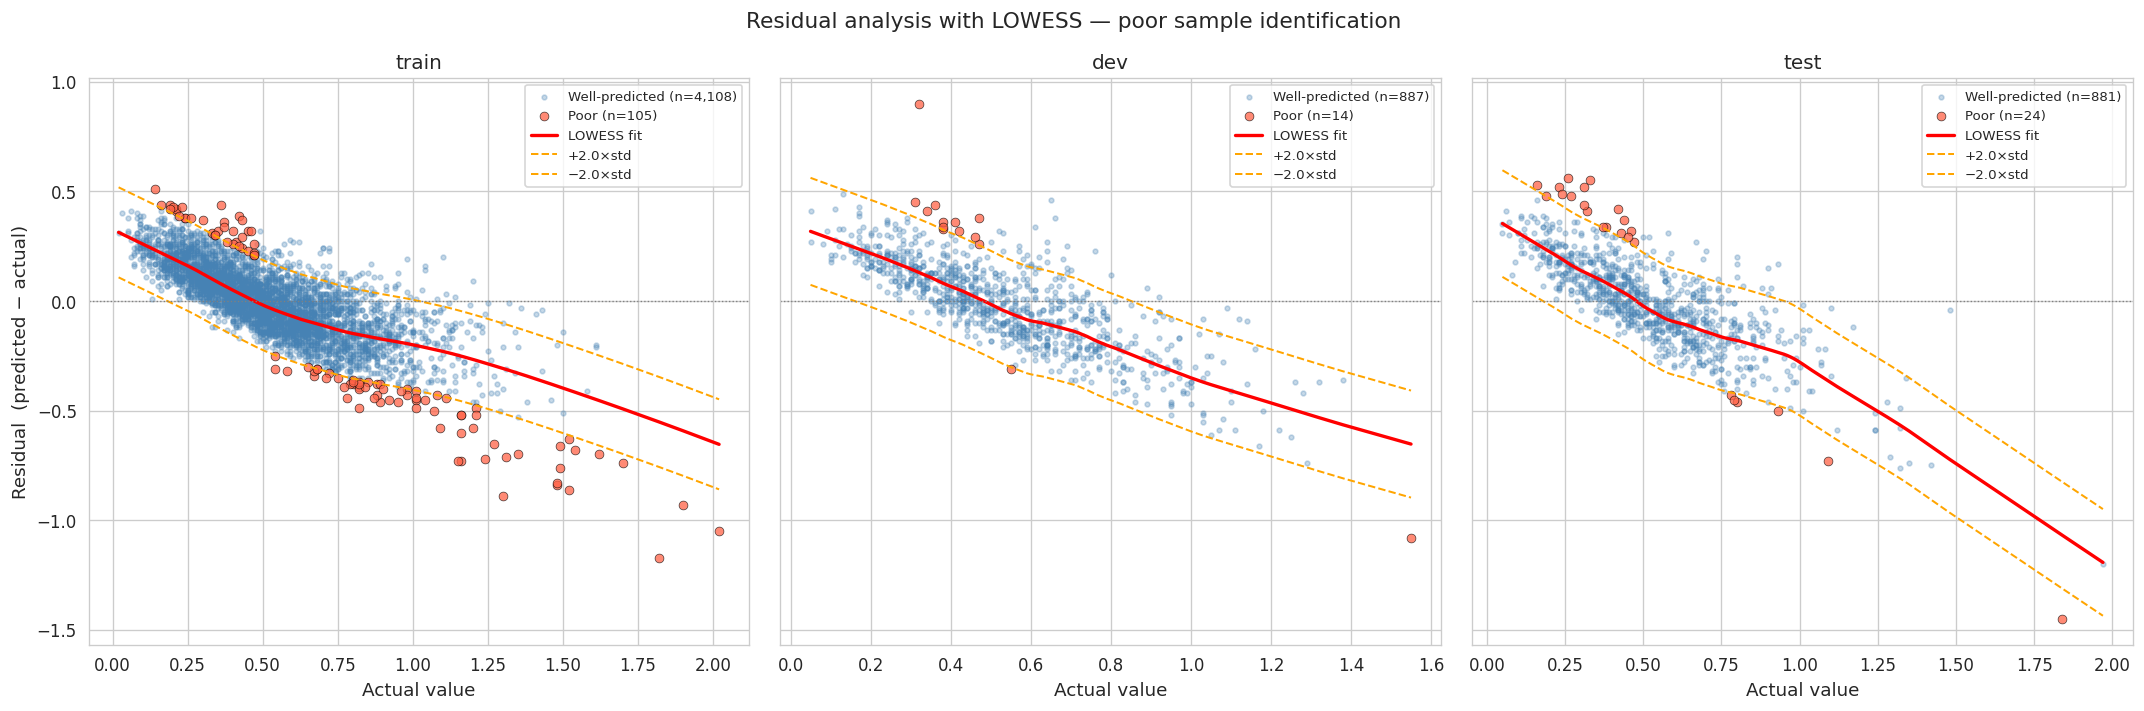

In [39]:
splits = df['split'].unique().tolist()
fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, split_name in zip(axes, splits):
    sub  = df[df['split'] == split_name]
    a    = sub['actual'].values
    r    = sub['residual'].values
    lp   = sub['loess_pred'].values
    thr  = sub['threshold'].iloc[0]
    poor = sub['is_poor'].values

    sort_idx = np.argsort(a)
    a_s  = a[sort_idx]
    lp_s = lp[sort_idx]

    ax.scatter(a[~poor], r[~poor], alpha=0.3, s=8, color='steelblue',
               label=f'Well-predicted (n={(~poor).sum():,})')
    ax.scatter(a[poor], r[poor], alpha=0.75, s=28, color='tomato',
               edgecolors='black', linewidths=0.4,
               label=f'Poor (n={poor.sum():,})')
    ax.plot(a_s, lp_s, color='red', linewidth=2.0, label='LOWESS fit')
    ax.plot(a_s, lp_s + thr, color='orange', linestyle='--', linewidth=1.2,
            label=f'+{STD_THRESHOLD}×std')
    ax.plot(a_s, lp_s - thr, color='orange', linestyle='--', linewidth=1.2,
            label=f'−{STD_THRESHOLD}×std')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Actual value', fontsize=11)
    ax.set_title(split_name, fontsize=12)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Residual  (predicted − actual)', fontsize=11)
fig.suptitle('Residual analysis with LOWESS — poor sample identification', fontsize=13)
fig.tight_layout()
plt.show()


## 4. Distribution of actual values — are poor samples biased to the tails?

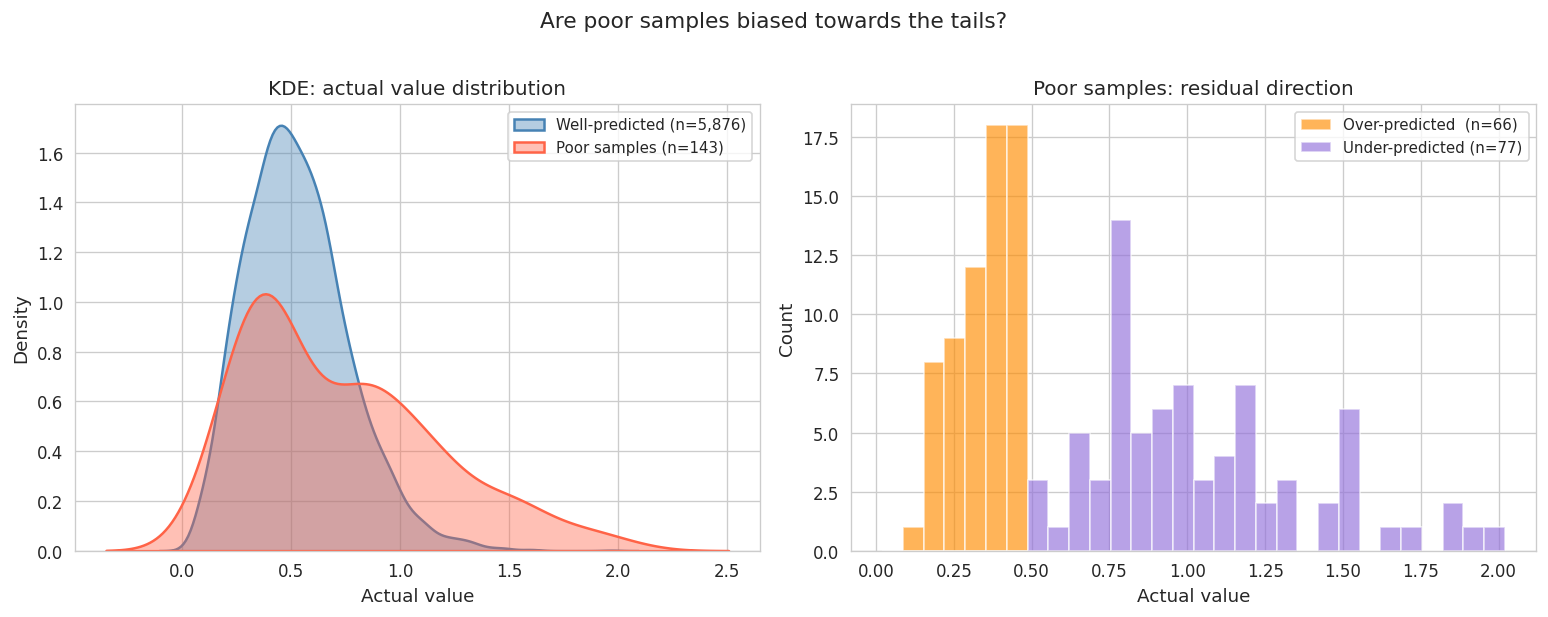


Poor sample actual-value summary:
count    143.0000
mean       0.7272
std        0.4379
min        0.1400
25%        0.3800
50%        0.6700
75%        1.0100
max        2.0200
Name: actual, dtype: float64

All samples actual-value summary:
count    6019.0000
mean        0.5325
std         0.2443
min         0.0200
25%         0.3600
50%         0.5100
75%         0.6700
max         2.0200
Name: actual, dtype: float64


In [41]:
#df = df[df['split'] == 'train']   # focus on train split for stratification analysis
dfOrig = df.copy()   # keep original for later splits
poor_df = df[df['is_poor']]
good_df = df[~df['is_poor']]
#poor_df  = df[df['is_poor'] & (df['split'] == 'train')]
#good_df  = df[~df['is_poor'] & (df['split'] == 'train')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── KDE overlay: poor vs well-predicted ──────────────────────────────────────
ax = axes[0]
sns.kdeplot(good_df['actual'],  ax=ax, color='steelblue', fill=True, alpha=0.4,
            linewidth=1.5, label=f'Well-predicted (n={len(good_df):,})')
sns.kdeplot(poor_df['actual'],  ax=ax, color='tomato',    fill=True, alpha=0.4,
            linewidth=1.5, label=f'Poor samples (n={len(poor_df):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('KDE: actual value distribution', fontsize=12)
ax.legend(fontsize=9)

# ── Histogram of poor samples, split by over- / under-prediction ─────────────
ax = axes[1]
over  = poor_df[poor_df['residual'] > 0]['actual']
under = poor_df[poor_df['residual'] < 0]['actual']
bins  = np.histogram_bin_edges(df['actual'], bins=30)
ax.hist(over,  bins=bins, color='darkorange',   alpha=0.65,
        label=f'Over-predicted  (n={len(over):,})')
ax.hist(under, bins=bins, color='mediumpurple', alpha=0.65,
        label=f'Under-predicted (n={len(under):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Poor samples: residual direction', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Are poor samples biased towards the tails?', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nPoor sample actual-value summary:')
print(poor_df['actual'].describe().round(4))
print('\nAll samples actual-value summary:')
print(df['actual'].describe().round(4))

## 5. Load input features

In [42]:
EXTRA_FEAT_PATH  = os.path.join(REPO_ROOT, 'output/data/codons/extraFeatures.csv')
VIENNA_FEAT_PATH = os.path.join(REPO_ROOT, 'output/data/codons/vienna_features.csv')

extra_df = pd.read_csv(EXTRA_FEAT_PATH, index_col=0)
extra_df.index = extra_df.index.astype(str)

vienna_df = pd.read_csv(VIENNA_FEAT_PATH)
if 'id' in vienna_df.columns:
    vienna_df = vienna_df.set_index('id')[['mfe']]
vienna_df.index = vienna_df.index.astype(str)

features_df = extra_df.join(vienna_df, how='left')

# Drop label columns — not input features
drop_cols = [c for c in ['Decay Rate', 'Residuals'] if c in features_df.columns]
features_df = features_df.drop(columns=drop_cols)

print(f'Feature matrix: {features_df.shape[0]:,} transcripts × {features_df.shape[1]} features')
print('Columns:', features_df.columns.tolist())

Feature matrix: 6,062 transcripts × 68 features
Columns: ["5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA', 'GGG', 'mfe']


## 6. Merge predictions with features

In [43]:
merged = df.set_index('id').join(features_df, how='inner')

n_matched   = len(merged)
n_unmatched = len(df) - n_matched
print(f'Matched to features : {n_matched:,}')
print(f'Unmatched (no feat) : {n_unmatched:,}')
print(f'Poor after merge    : {merged["is_poor"].sum():,}')
print(f'Good after merge    : {(~merged["is_poor"]).sum():,}')

feature_cols = [c for c in features_df.columns if c in merged.columns]
print(f'\n{len(feature_cols)} feature columns available for comparison')

Matched to features : 6,019
Unmatched (no feat) : 0
Poor after merge    : 143
Good after merge    : 5,876

68 feature columns available for comparison


## 7. Mann-Whitney U test for each feature (FDR corrected)

In [44]:
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


Significant features (FDR < 0.05): 8


,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,CAT,0.007812,0.010526,0.008731,0.012111,-0.366049,324916.5,0.000003,0.000238,True
1,CDS Length,1107.000000,1455.000000,1537.342657,1936.258509,-0.217443,334672.5,0.000031,0.001070,True
2,mfe,98.670000,128.880000,128.485874,169.234991,-0.266198,338893.5,0.000081,0.001826,True
3,5' UTR Length,107.000000,138.000000,186.293706,231.027910,-0.192414,343468.0,0.000188,0.003202,True
4,ATT,0.015385,0.013051,0.016635,0.014189,0.288089,481647.0,0.002734,0.035940,True
5,TCA,0.006667,0.008277,0.008691,0.010251,-0.179553,359621.5,0.003171,0.035940,True
6,3' UTR Length,169.000000,238.000000,306.265734,362.490470,-0.154535,361345.0,0.004192,0.040719,True
7,CCA,0.012500,0.014279,0.013985,0.016648,-0.222984,362812.5,0.005235,0.044497,True
8,TCT,0.005420,0.007282,0.007516,0.008564,-0.145838,364929.5,0.007084,0.053521,False
9,GGA,0.014634,0.016393,0.016594,0.019223,-0.192304,368657.0,0.012167,0.063643,False


In [45]:
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


Significant features (FDR < 0.05): 8


,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,CAT,0.007812,0.010526,0.008731,0.012111,-0.366049,324916.5,0.000003,0.000238,True
1,CDS Length,1107.000000,1455.000000,1537.342657,1936.258509,-0.217443,334672.5,0.000031,0.001070,True
2,mfe,98.670000,128.880000,128.485874,169.234991,-0.266198,338893.5,0.000081,0.001826,True
3,5' UTR Length,107.000000,138.000000,186.293706,231.027910,-0.192414,343468.0,0.000188,0.003202,True
4,ATT,0.015385,0.013051,0.016635,0.014189,0.288089,481647.0,0.002734,0.035940,True
5,TCA,0.006667,0.008277,0.008691,0.010251,-0.179553,359621.5,0.003171,0.035940,True
6,3' UTR Length,169.000000,238.000000,306.265734,362.490470,-0.154535,361345.0,0.004192,0.040719,True
7,CCA,0.012500,0.014279,0.013985,0.016648,-0.222984,362812.5,0.005235,0.044497,True
8,TCT,0.005420,0.007282,0.007516,0.008564,-0.145838,364929.5,0.007084,0.053521,False
9,GGA,0.014634,0.016393,0.016594,0.019223,-0.192304,368657.0,0.012167,0.063643,False


## 8. Volcano plot — effect size vs significance

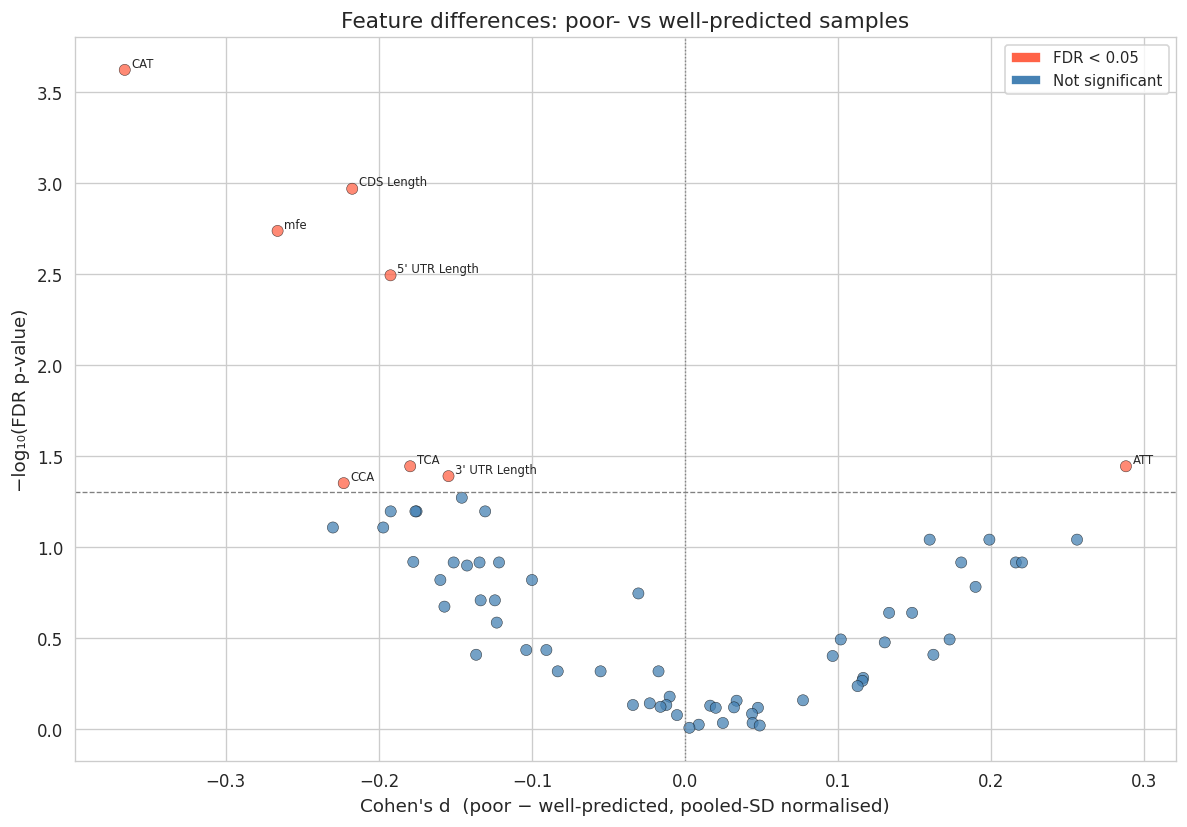

In [46]:
stats_df['neg_log10_padj'] = -np.log10(stats_df['padj'].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(10, 7))

colors = stats_df['sig_fdr'].map({True: 'tomato', False: 'steelblue'})
ax.scatter(stats_df['cohens_d'], stats_df['neg_log10_padj'],
           c=colors, alpha=0.75, s=45, edgecolors='k', linewidths=0.3)

# Label top 15 significant features
for _, row in stats_df[stats_df['sig_fdr']].head(15).iterrows():
    ax.annotate(row['feature'],
                xy=(row['cohens_d'], row['neg_log10_padj']),
                xytext=(4, 2), textcoords='offset points', fontsize=7)

ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel("Cohen's d  (poor − well-predicted, pooled-SD normalised)", fontsize=11)
ax.set_ylabel('−log₁₀(FDR p-value)', fontsize=11)
ax.set_title('Feature differences: poor- vs well-predicted samples', fontsize=13)
ax.legend(handles=[
    Patch(facecolor='tomato',    label='FDR < 0.05'),
    Patch(facecolor='steelblue', label='Not significant'),
], fontsize=9)
fig.tight_layout()
plt.show()


## 9. Violin plots — structural features (lengths, GC content, MFE)



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

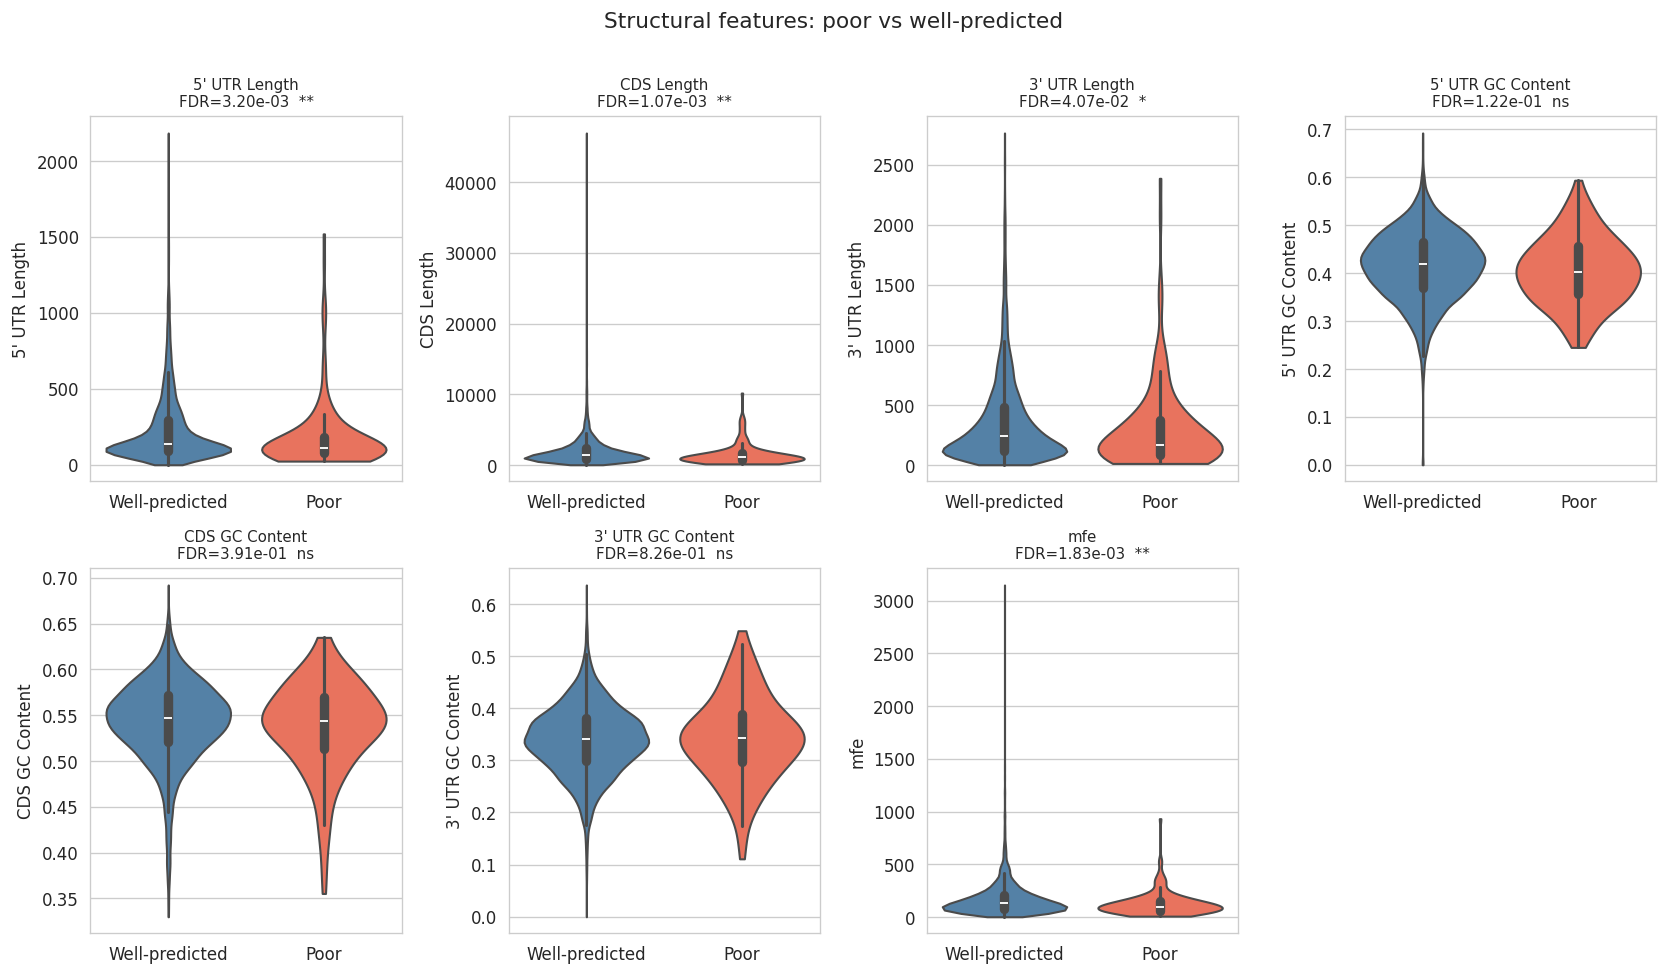

In [47]:
structural_features = [
    "5' UTR Length", "CDS Length", "3' UTR Length",
    "5' UTR GC Content", "CDS GC Content", "3' UTR GC Content",
    "mfe",
]
structural_features = [f for f in structural_features if f in merged.columns]

palette = {'Poor': 'tomato', 'Well-predicted': 'steelblue'}

plot_df = merged[structural_features + ['is_poor']].copy()
plot_df['Group'] = plot_df['is_poor'].map({True: 'Poor', False: 'Well-predicted'})

n_cols = 4
n_rows = int(np.ceil(len(structural_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, feat in zip(axes, structural_features):
    sns.violinplot(data=plot_df, x='Group', y=feat, palette=palette,
                   inner='box', ax=ax, cut=0,
                   order=['Well-predicted', 'Poor'])
    row = stats_df[stats_df['feature'] == feat]
    if not row.empty:
        p   = row['padj'].values[0]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{feat}\nFDR={p:.2e}  {sig}', fontsize=9)
    else:
        ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')

for ax in axes[len(structural_features):]:
    ax.set_visible(False)

fig.suptitle('Structural features: poor vs well-predicted', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 10. Violin plots — top codon frequency differences

61 codon columns; top 16 by FDR: ['CAT', 'ATT', 'TCA', 'CCA', 'TCT', 'GGA', 'GCG', 'CTA', 'CAA', 'CGA', 'AGC', 'GAG', 'ATC', 'AAG', 'GCA', 'CCG']




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

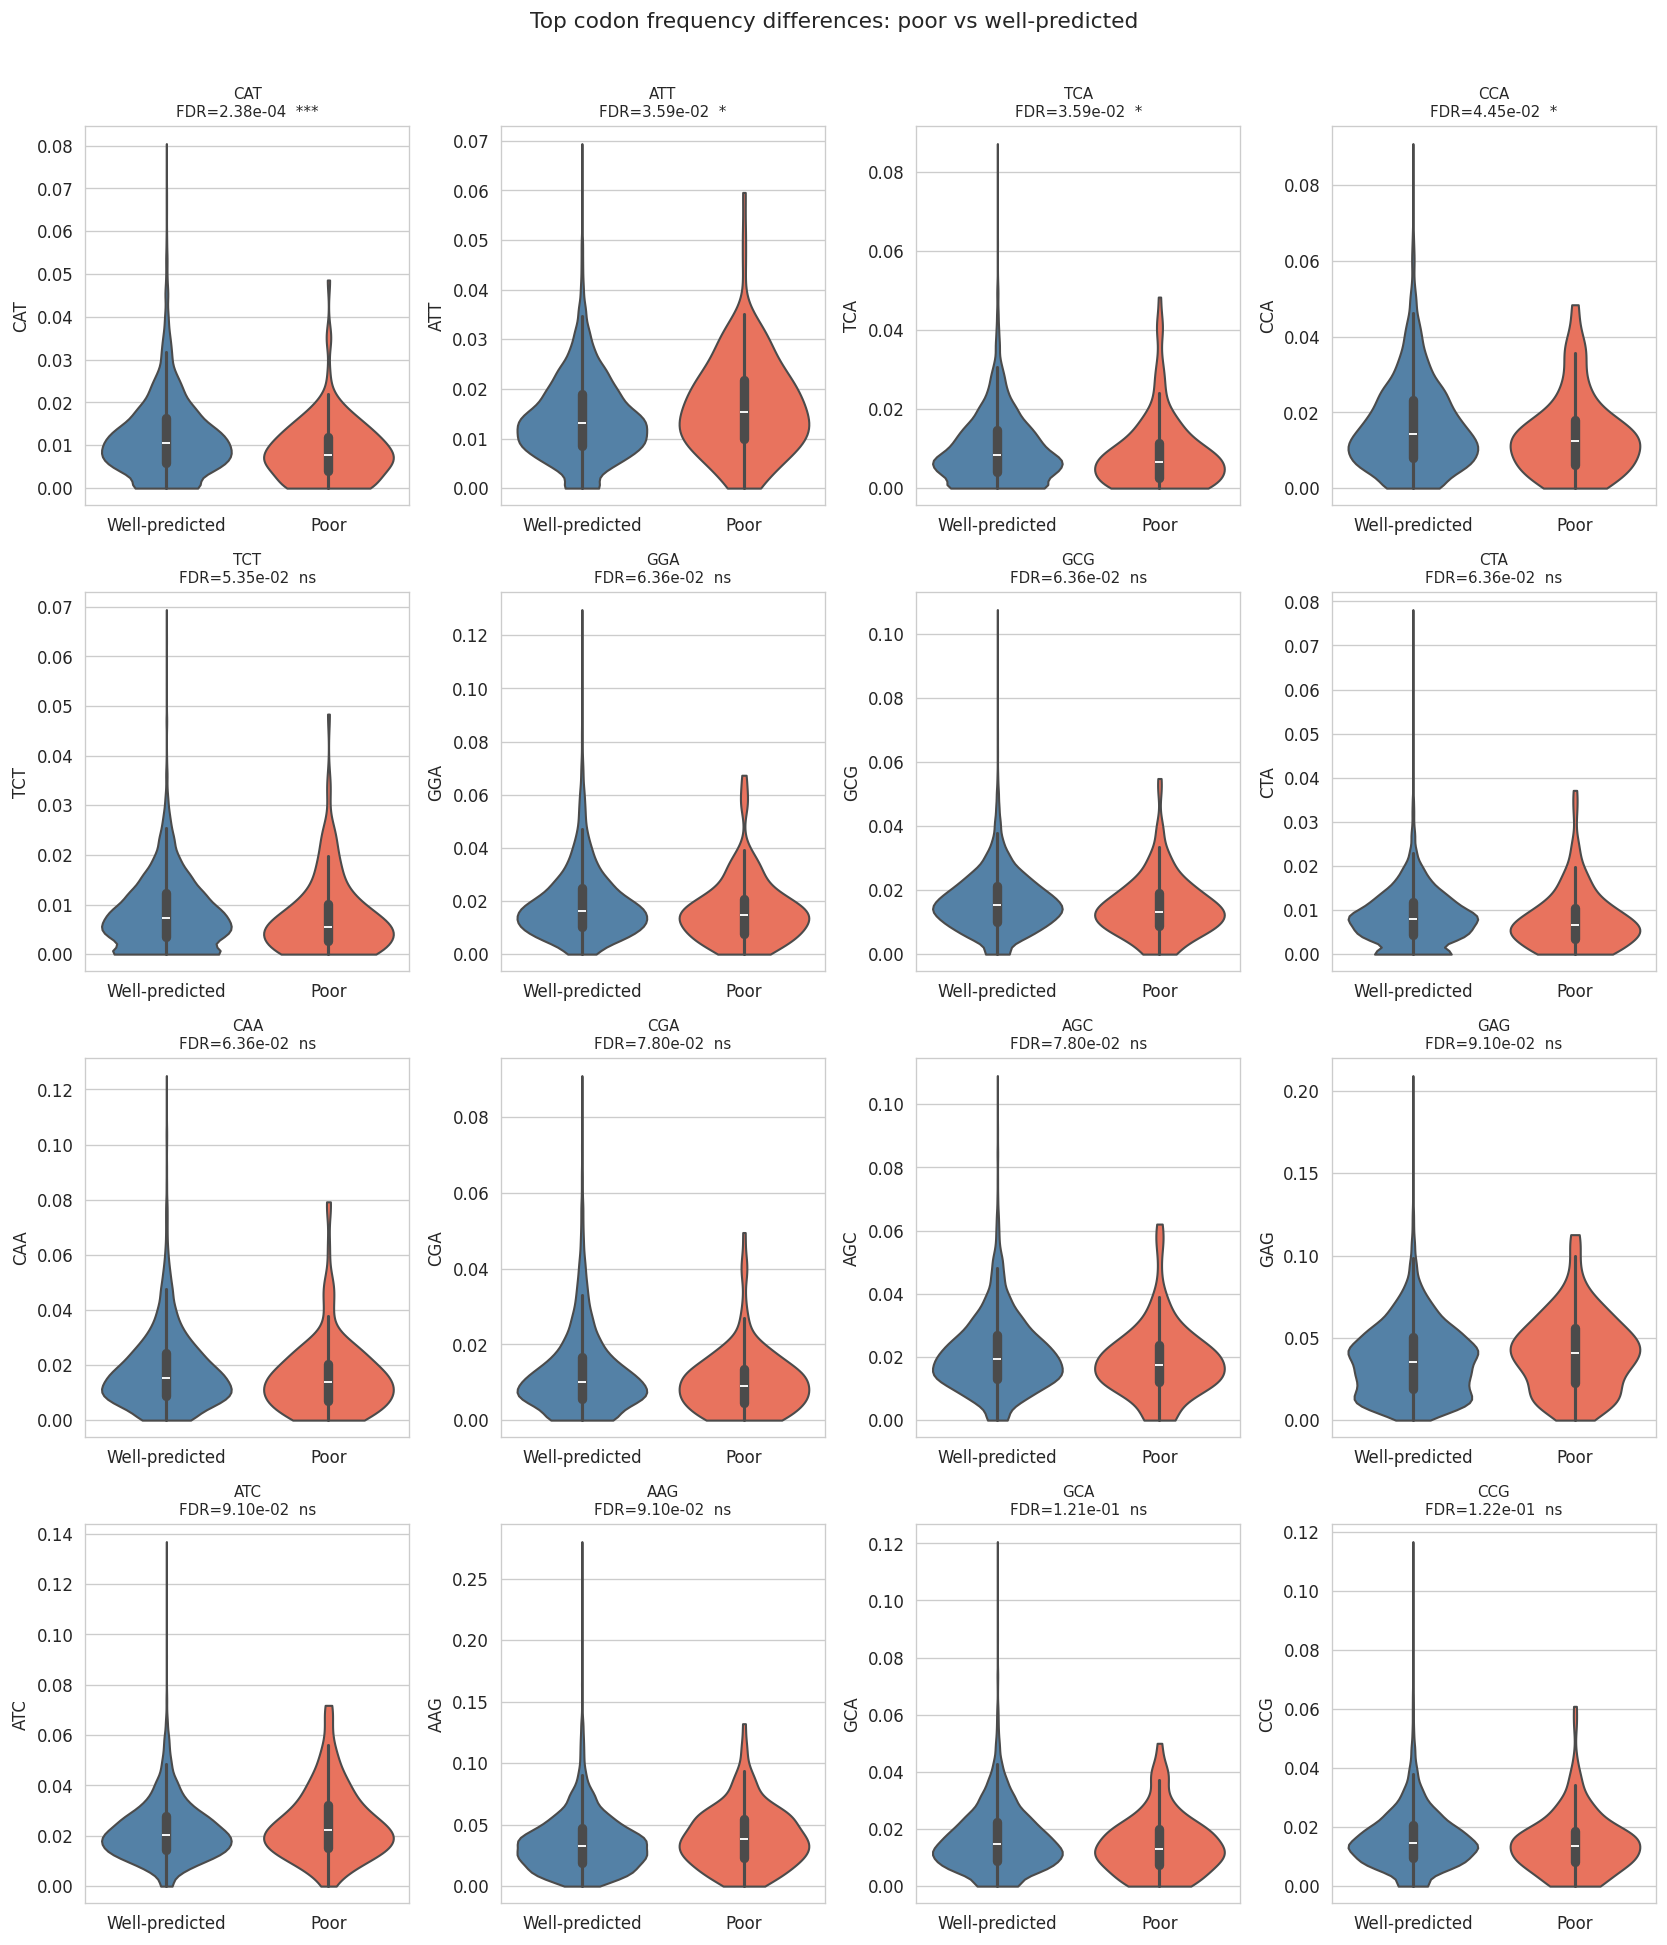

In [48]:
STANDARD_CODONS = {
    'TTT','TTC','TTA','TTG','CTT','CTC','CTA','CTG',
    'ATT','ATC','ATA','ATG','GTT','GTC','GTA','GTG',
    'TCT','TCC','TCA','TCG','AGT','AGC',
    'CCT','CCC','CCA','CCG','ACT','ACC','ACA','ACG',
    'GCT','GCC','GCA','GCG','TAT','TAC',
    'CAT','CAC','CAA','CAG','AAT','AAC','AAA','AAG',
    'GAT','GAC','GAA','GAG','TGT','TGC','TGG',
    'CGT','CGC','CGA','CGG','AGA','AGG',
    'GGT','GGC','GGA','GGG',
}

codon_cols  = [c for c in feature_cols if c in STANDARD_CODONS]
codon_stats = stats_df[stats_df['feature'].isin(codon_cols)]
top_codons  = codon_stats.head(16)['feature'].tolist()

print(f'{len(codon_cols)} codon columns; top 16 by FDR: {top_codons}')

codon_plot_df = merged[top_codons + ['is_poor']].copy()
codon_plot_df['Group'] = codon_plot_df['is_poor'].map({True: 'Poor', False: 'Well-predicted'})

n_cols = 4
n_rows = int(np.ceil(len(top_codons) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, feat in zip(axes, top_codons):
    sns.violinplot(data=codon_plot_df, x='Group', y=feat, palette=palette,
                   inner='box', ax=ax, cut=0,
                   order=['Well-predicted', 'Poor'])
    row = stats_df[stats_df['feature'] == feat]
    if not row.empty:
        p   = row['padj'].values[0]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{feat}\nFDR={p:.2e}  {sig}', fontsize=9)
    ax.set_xlabel('')

for ax in axes[len(top_codons):]:
    ax.set_visible(False)

fig.suptitle('Top codon frequency differences: poor vs well-predicted', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 11. Summary table of significant features

In [49]:
sig_df = stats_df[stats_df['sig_fdr']].copy()
sig_df['direction'] = np.where(
    sig_df['poor_median'] > sig_df['good_median'],
    'higher in poor', 'lower in poor'
)

display_cols = ['feature', 'poor_median', 'good_median', 'cohens_d', 'padj', 'direction']
print(f'{len(sig_df)} significant features (FDR < 0.05):')
sig_df[display_cols].round(5)


8 significant features (FDR < 0.05):


,feature,poor_median,good_median,cohens_d,padj,direction
0,CAT,0.00781,0.01053,-0.36605,0.00024,lower in poor
1,CDS Length,1107.00000,1455.00000,-0.21744,0.00107,lower in poor
2,mfe,98.67000,128.88000,-0.26620,0.00183,lower in poor
3,5' UTR Length,107.00000,138.00000,-0.19241,0.00320,lower in poor
4,ATT,0.01538,0.01305,0.28809,0.03594,higher in poor
5,TCA,0.00667,0.00828,-0.17955,0.03594,lower in poor
6,3' UTR Length,169.00000,238.00000,-0.15453,0.04072,lower in poor
7,CCA,0.01250,0.01428,-0.22298,0.04450,lower in poor


## 12. Directional breakdown for top-hit feature

Split poor samples into **over-predicted** (`deviation > 0`, +std side) and **under-predicted** (`deviation < 0`, −std side) and compare each against the well-predicted samples. This checks whether an enrichment signal is driven by one error direction.

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: CAT
poor (+std, over-predicted) vs good  —  p=5.277e-05  Cohen's d=-0.457
poor (−std, under-predicted) vs good  —  p=0.008855  Cohen's d=-0.287




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


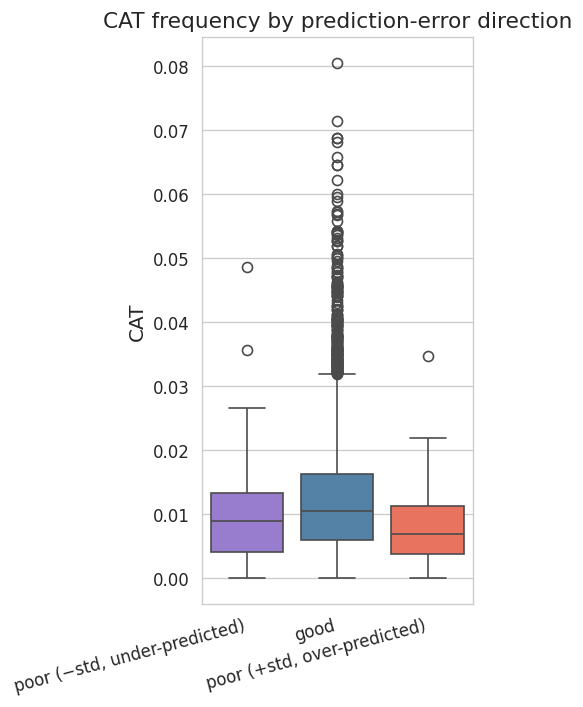

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: CDS Length
poor (+std, over-predicted) vs good  —  p=0.0008677  Cohen's d=-0.271
poor (−std, under-predicted) vs good  —  p=0.008704  Cohen's d=-0.171




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


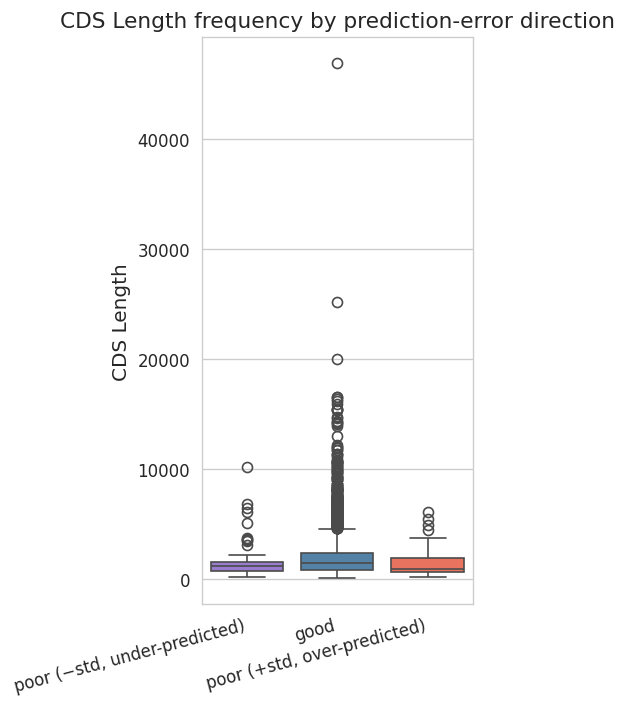

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: mfe
poor (+std, over-predicted) vs good  —  p=1.782e-05  Cohen's d=-0.414
poor (−std, under-predicted) vs good  —  p=0.1515  Cohen's d=-0.138




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


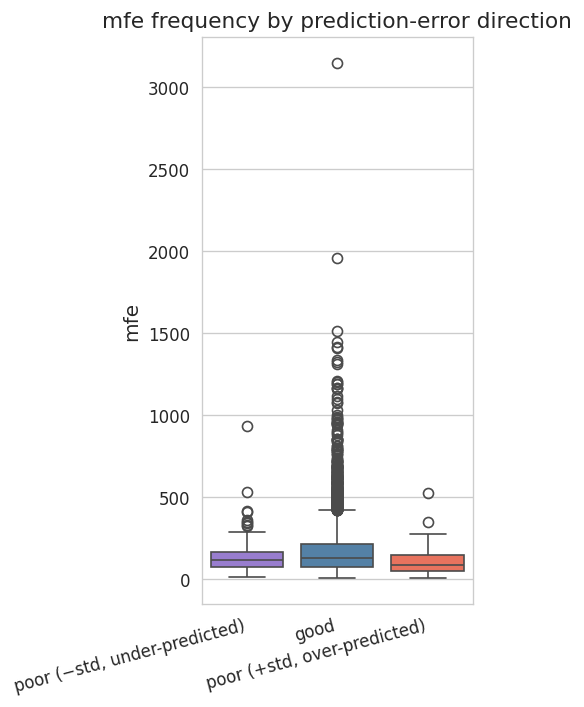

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: 5' UTR Length
poor (+std, over-predicted) vs good  —  p=1.036e-10  Cohen's d=-0.553
poor (−std, under-predicted) vs good  —  p=0.3899  Cohen's d=0.114




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


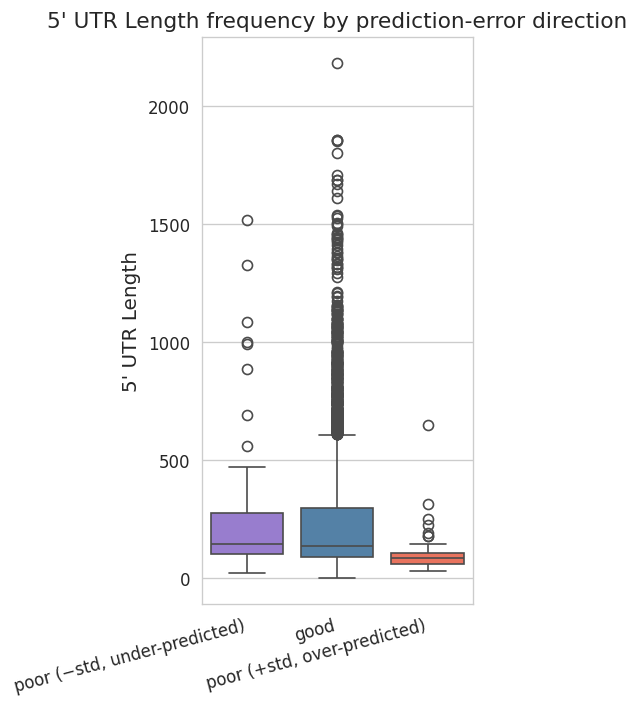

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: ATT
poor (+std, over-predicted) vs good  —  p=0.002617  Cohen's d=0.396
poor (−std, under-predicted) vs good  —  p=0.1862  Cohen's d=0.197




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


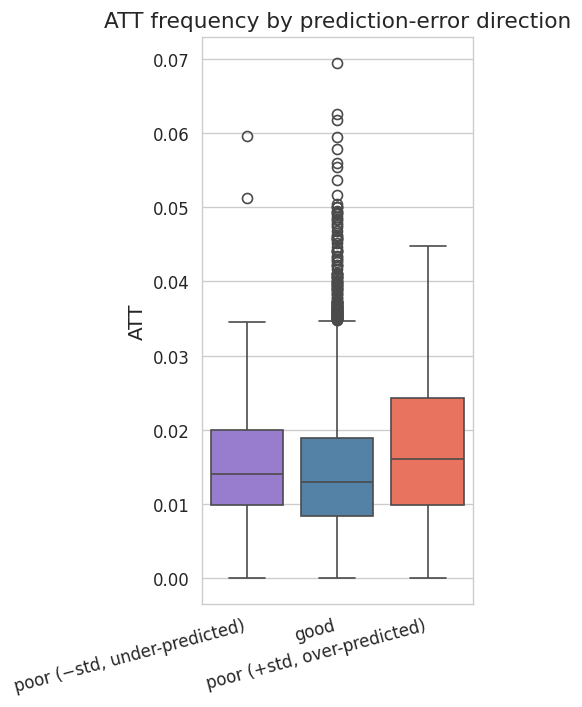

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: TCA
poor (+std, over-predicted) vs good  —  p=0.0573  Cohen's d=-0.217
poor (−std, under-predicted) vs good  —  p=0.02233  Cohen's d=-0.148




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


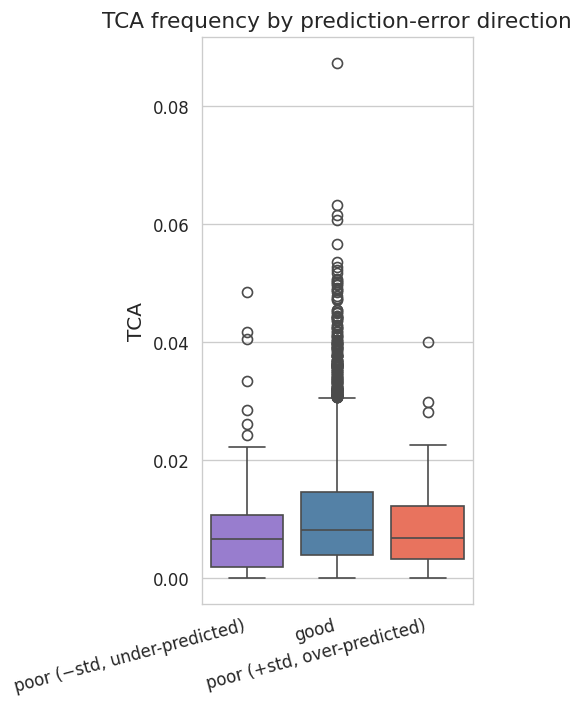

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: 3' UTR Length
poor (+std, over-predicted) vs good  —  p=1.999e-12  Cohen's d=-0.616
poor (−std, under-predicted) vs good  —  p=0.009795  Cohen's d=0.238




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


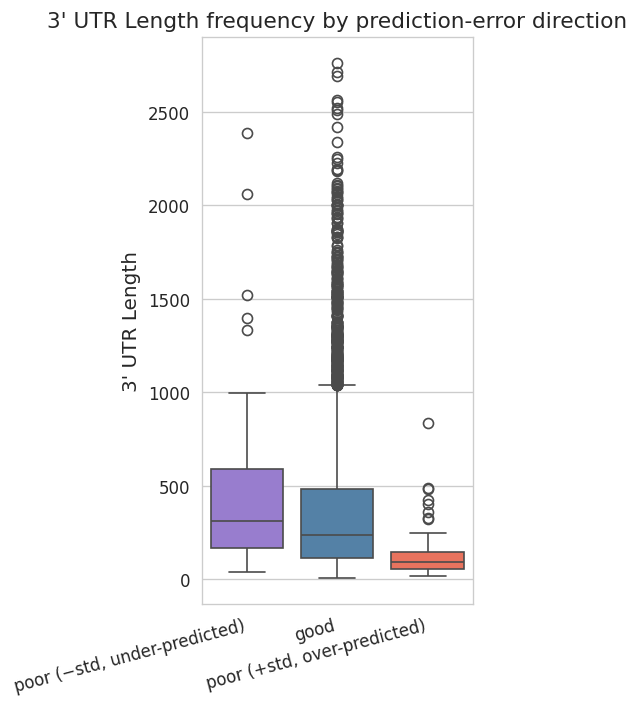

poor (−std, under-predicted)       : 77
good                               : 5,876
poor (+std, over-predicted)        : 66

Focus feature: CCA
poor (+std, over-predicted) vs good  —  p=0.1041  Cohen's d=-0.215
poor (−std, under-predicted) vs good  —  p=0.02018  Cohen's d=-0.230




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


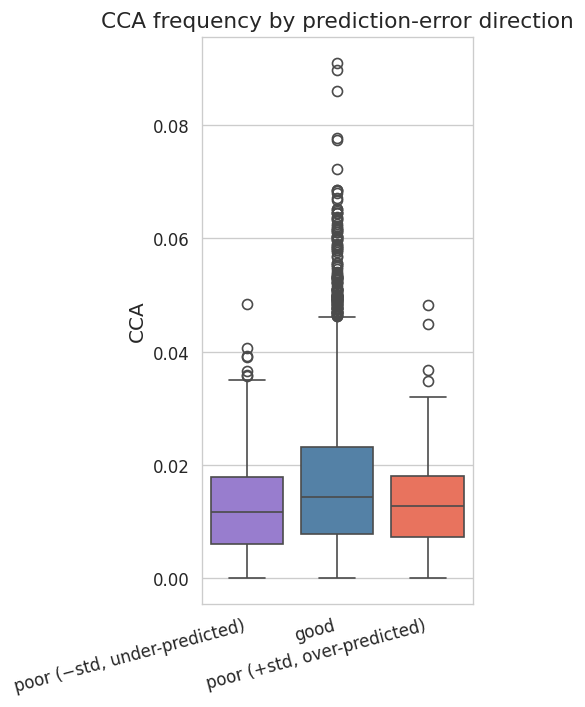

In [50]:
# ── Pick the feature to investigate (default: top MWU hit) ───────────────────
for i in range(len(sig_df)):
    FOCUS_FEATURE = stats_df.iloc[i]['feature']   # change to e.g. 'CAT' to hard-code

    # ── Label each sample with its prediction-error group ─────────────────────────
    #   poor_over  : is_poor AND deviation > 0  (model over-estimated)
    #   poor_under : is_poor AND deviation < 0  (model under-estimated)
    #   good       : ~is_poor
    def _error_group(row):
        if not row['is_poor']:
            return 'good'
        return 'poor (+std, over-predicted)' if row['deviation'] > 0 else 'poor (−std, under-predicted)'

    merged['error_group'] = merged.apply(_error_group, axis=1)

    group_order  = ['poor (−std, under-predicted)', 'good', 'poor (+std, over-predicted)']
    group_colors = {
        'poor (+std, over-predicted)': 'tomato',
        'good':                         'steelblue',
        'poor (−std, under-predicted)': 'mediumpurple',
    }

    # ── Count per group ───────────────────────────────────────────────────────────
    for g in group_order:
        n = (merged['error_group'] == g).sum()
        print(f'{g:35s}: {n:,}')

    print(f'\nFocus feature: {FOCUS_FEATURE}')

    # ── Pairwise MWU: each poor group vs good ─────────────────────────────────────
    feat_data = {g: merged.loc[merged['error_group'] == g, FOCUS_FEATURE].dropna()
                 for g in group_order}

    good_vals = feat_data['good']
    for g in ['poor (+std, over-predicted)', 'poor (−std, under-predicted)']:
        vals = feat_data[g]
        if len(vals) >= 2:
            stat, pval = mannwhitneyu(vals, good_vals, alternative='two-sided')
            n1, n2 = len(vals), len(good_vals)
            pooled   = np.sqrt(((n1-1)*vals.std()**2 + (n2-1)*good_vals.std()**2) / (n1+n2-2))
            d = (vals.mean() - good_vals.mean()) / pooled if pooled > 0 else 0.0
            print(f'{g} vs good  —  p={pval:.4g}  Cohen\'s d={d:.3f}')

    # ── Violin + strip plot ───────────────────────────────────────────────────────
    plot_data = merged[merged['error_group'].isin(group_order)].copy()

    fig, ax = plt.subplots(figsize=(4, 6))
    #sns.violinplot(data=plot_data, x='error_group', y=FOCUS_FEATURE,
    #               order=group_order,
    #               palette=group_colors,
    #               inner='box', ax=ax)#linewidth=0.8, 
    sns.boxplot(data=plot_data, x='error_group', y=FOCUS_FEATURE,
                  order=group_order,
                  palette=group_colors,)
                  #alpha=0.25, size=2.5, jitter=True, ax=ax)

    ax.set_xlabel('')
    ax.set_ylabel(FOCUS_FEATURE, fontsize=12)
    ax.set_title(f'{FOCUS_FEATURE} frequency by prediction-error direction', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    fig.tight_layout()
    plt.show()


## 13. Zone-matched comparison: poor vs good within the same LOWESS region

Because lengths (and GC content) are correlated with actual RD, a naive poor-vs-good comparison is confounded by the fact that poor samples are biased to particular RD values (e.g. tails). Here we compare each poor group only to the **good samples in the same LOWESS zone**:

* **+std poor** (over-predicted, `loess_pred > 0`) vs **good where `loess_pred > 0`**
* **-std poor** (under-predicted, `loess_pred <= 0`) vs **good where `loess_pred <= 0`**

Any feature difference that survives this matched comparison cannot be explained purely by the zone-level RD bias.

+std  poor (over-pred)  : 66
good in +loess zone     : 2,631
-std  poor (under-pred) : 77
good in -loess zone     : 3,245

+std poor vs zone-matched good:
          feature  cohens_d   padj  sig
              CAT   -0.5162 0.0000 True
       CDS Length   -0.3074 0.0001 True
              mfe   -0.4808 0.0000 True
    5' UTR Length   -0.6380 0.0000 True
              ATT    0.4072 0.0027 True
              TCA   -0.2275 0.0473 True
    3' UTR Length   -0.7137 0.0000 True
5' UTR GC Content   -0.6387 0.0000 True
   CDS GC Content   -0.4851 0.0000 True
3' UTR GC Content   -0.5527 0.0000 True

-std poor vs zone-matched good:
          feature  cohens_d   padj   sig
              CAT   -0.2356 0.0675 False
       CDS Length   -0.1402 0.0718 False
              mfe   -0.0768 0.6738 False
    5' UTR Length    0.1748 0.1020 False
              ATT    0.1890 0.2262 False
              TCA   -0.1380 0.0617 False
    3' UTR Length    0.3895 0.0005  True
5' UTR GC Content    0.2702 0.0617 False
   



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

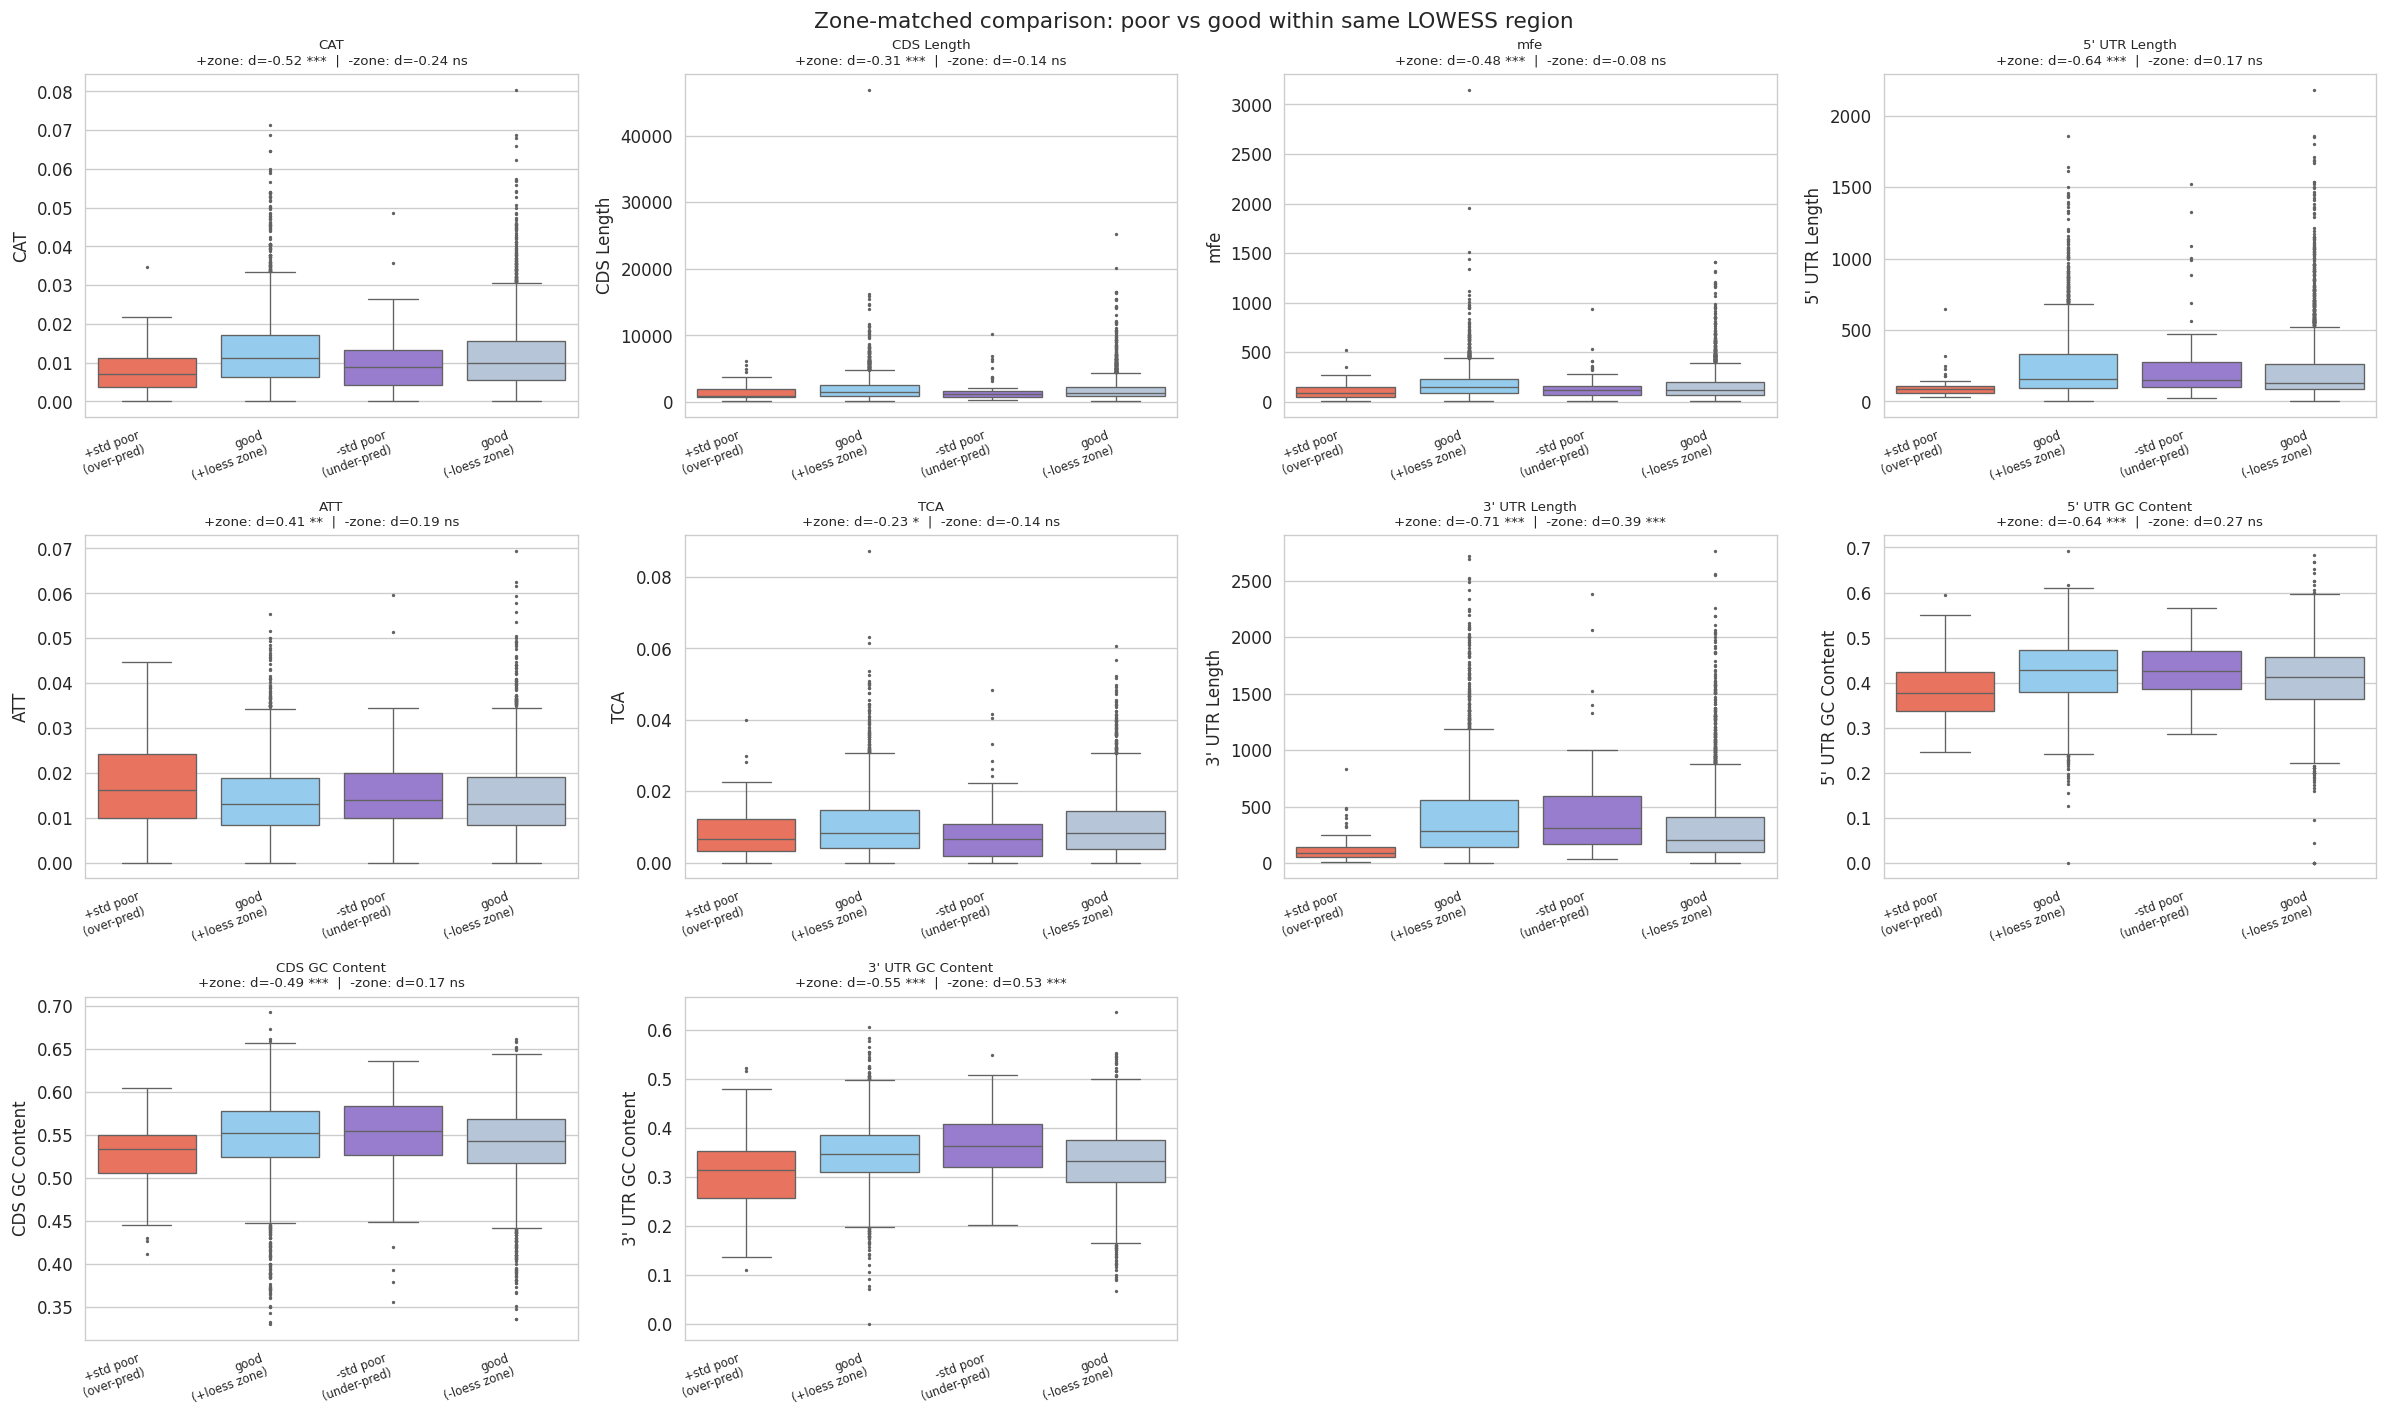

In [51]:
# Features to plot in this section (top 6 from overall MWU + structural features)
ZONE_FEATURES = (
    stats_df.head(6)['feature'].tolist()
    + [f for f in ["5' UTR Length", "CDS Length", "3' UTR Length",
                   "5' UTR GC Content", "CDS GC Content", "3' UTR GC Content", "mfe"]
       if f in feature_cols]
)
ZONE_FEATURES = list(dict.fromkeys(ZONE_FEATURES))   # deduplicate, preserve order

# ── Build zone-matched groups from merged (which has loess_pred + is_poor) ───
poor_over  = merged[ merged['is_poor'] & (merged['deviation'] > 0)]
poor_under = merged[ merged['is_poor'] & (merged['deviation'] < 0)]
good_pos   = merged[~merged['is_poor'] & (merged['loess_pred'] > 0)]
good_neg   = merged[~merged['is_poor'] & (merged['loess_pred'] <= 0)]

print(f'+std  poor (over-pred)  : {len(poor_over):,}')
print(f'good in +loess zone     : {len(good_pos):,}')
print(f'-std  poor (under-pred) : {len(poor_under):,}')
print(f'good in -loess zone     : {len(good_neg):,}')

# ── MWU for zone-matched comparisons ─────────────────────────────────────────
def _zone_stats(group_a, label_a, group_b, label_b, cols):
    rows = []
    for col in cols:
        a = group_a[col].dropna()
        b = group_b[col].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        stat, pval = mannwhitneyu(a, b, alternative='two-sided')
        n1, n2 = len(a), len(b)
        pooled = np.sqrt(((n1-1)*a.std()**2 + (n2-1)*b.std()**2) / (n1+n2-2))
        d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
        rows.append({'feature': col, 'cohens_d': d, 'p_value': pval,
                     'comparison': f'{label_a} vs {label_b}'})
    out = pd.DataFrame(rows)
    _, padj, _, _ = multipletests(out['p_value'], method='fdr_bh')
    out['padj'] = padj
    out['sig']  = out['padj'] < 0.05
    return out

zone_stats_pos = _zone_stats(poor_over,  '+std poor', good_pos, 'good (+zone)', ZONE_FEATURES)
zone_stats_neg = _zone_stats(poor_under, '-std poor', good_neg, 'good (-zone)', ZONE_FEATURES)

print('\n+std poor vs zone-matched good:')
print(zone_stats_pos[['feature','cohens_d','padj','sig']].round(4).to_string(index=False))
print('\n-std poor vs zone-matched good:')
print(zone_stats_neg[['feature','cohens_d','padj','sig']].round(4).to_string(index=False))

# ── Build long-form plotting frame with zone-matched group labels ─────────────
frames = []
for sub, label in [(poor_over,  '+std poor\n(over-pred)'),
                   (good_pos,   'good\n(+loess zone)'),
                   (poor_under, '-std poor\n(under-pred)'),
                   (good_neg,   'good\n(-loess zone)')]:
    tmp = sub[ZONE_FEATURES].copy()
    tmp['group'] = label
    frames.append(tmp)

zone_df    = pd.concat(frames)
group_order = ['+std poor\n(over-pred)', 'good\n(+loess zone)',
               '-std poor\n(under-pred)', 'good\n(-loess zone)']
zone_colors = {
    '+std poor\n(over-pred)':   'tomato',
    'good\n(+loess zone)':      'lightskyblue',
    '-std poor\n(under-pred)':  'mediumpurple',
    'good\n(-loess zone)':      'lightsteelblue',
}

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(ZONE_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

# Build a quick lookup: feature -> (d_pos, sig_pos, d_neg, sig_neg)
zp = zone_stats_pos.set_index('feature')
zn = zone_stats_neg.set_index('feature')

for ax, feat in zip(axes, ZONE_FEATURES):
    sns.boxplot(data=zone_df, x='group', y=feat,
                order=group_order, palette=zone_colors,
                linewidth=0.8, ax=ax, flierprops=dict(marker='.', markersize=2))
    # Annotate Cohen's d for each zone comparison
    lines = []
    if feat in zp.index:
        d, p = zp.loc[feat, 'cohens_d'], zp.loc[feat, 'padj']
        s = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        lines.append(f'+zone: d={d:.2f} {s}')
    if feat in zn.index:
        d, p = zn.loc[feat, 'cohens_d'], zn.loc[feat, 'padj']
        s = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        lines.append(f'-zone: d={d:.2f} {s}')
    ax.set_title(f'{feat}\n' + '  |  '.join(lines), fontsize=8)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)

for ax in axes[len(ZONE_FEATURES):]:
    ax.set_visible(False)

fig.suptitle('Zone-matched comparison: poor vs good within same LOWESS region', fontsize=13)
fig.tight_layout()
plt.show()




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


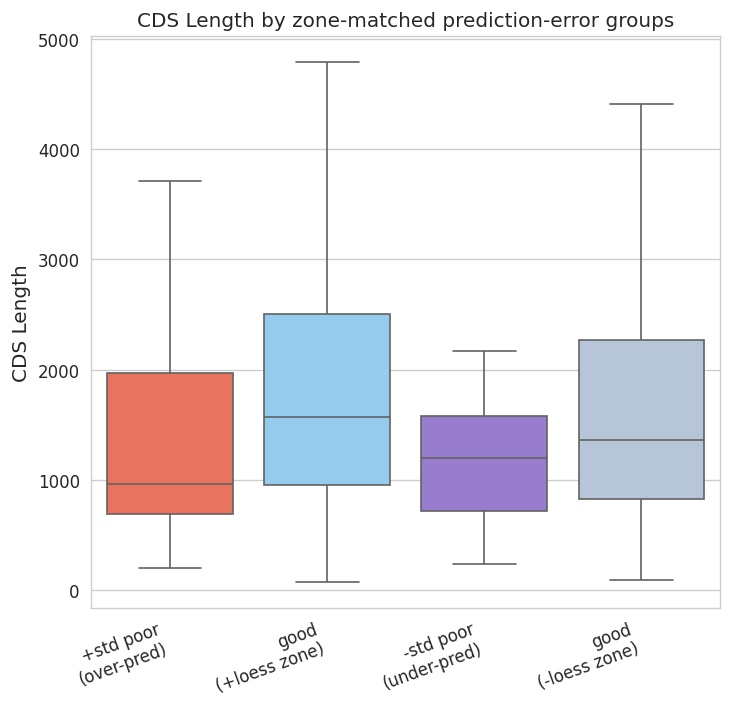



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


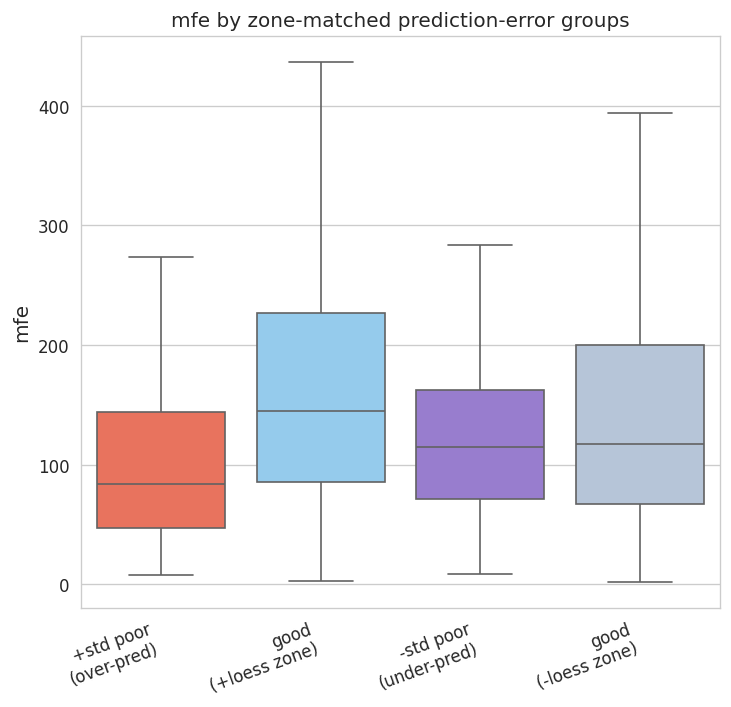

In [52]:
# Recreate 4-group zone-matched boxplot for i=1 (CDS Length), no outliers
for i in [1,2]:  # change index to plot different features from stats_df
    FOCUS_FEATURE = stats_df.iloc[i]['feature']  # expected: 'CDS Length'
    
    four_group_order = [
        '+std poor\n(over-pred)',
        'good\n(+loess zone)',
        '-std poor\n(under-pred)',
        'good\n(-loess zone)'
    ]
    four_group_colors = {
        '+std poor\n(over-pred)':  'tomato',
        'good\n(+loess zone)':     'lightskyblue',
        '-std poor\n(under-pred)': 'mediumpurple',
        'good\n(-loess zone)':     'lightsteelblue',
    }
    
    # Rebuild zone_df only if missing
    if 'zone_df' not in globals() or FOCUS_FEATURE not in zone_df.columns:
        poor_over  = merged[ merged['is_poor'] & (merged['deviation'] > 0)]
        poor_under = merged[ merged['is_poor'] & (merged['deviation'] < 0)]
        good_pos   = merged[~merged['is_poor'] & (merged['loess_pred'] > 0)]
        good_neg   = merged[~merged['is_poor'] & (merged['loess_pred'] <= 0)]
    
        frames = []
        for sub, label in [
            (poor_over,  '+std poor\n(over-pred)'),
            (good_pos,   'good\n(+loess zone)'),
            (poor_under, '-std poor\n(under-pred)'),
            (good_neg,   'good\n(-loess zone)')
        ]:
            tmp = sub[[FOCUS_FEATURE]].copy()
            tmp['group'] = label
            frames.append(tmp)
    
        zone_plot_data = pd.concat(frames, axis=0)
    else:
        zone_plot_data = zone_df[[FOCUS_FEATURE, 'group']].copy()
    
    fig, ax = plt.subplots(figsize=(6.2, 6))
    sns.boxplot(
        data=zone_plot_data,
        x='group',
        y=FOCUS_FEATURE,
        order=four_group_order,
        palette=four_group_colors,
        showfliers=False
    )
    
    ax.set_xlabel('')
    ax.set_ylabel(FOCUS_FEATURE, fontsize=12)
    ax.set_title(f'{FOCUS_FEATURE} by zone-matched prediction-error groups', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    fig.tight_layout()
    plt.show()

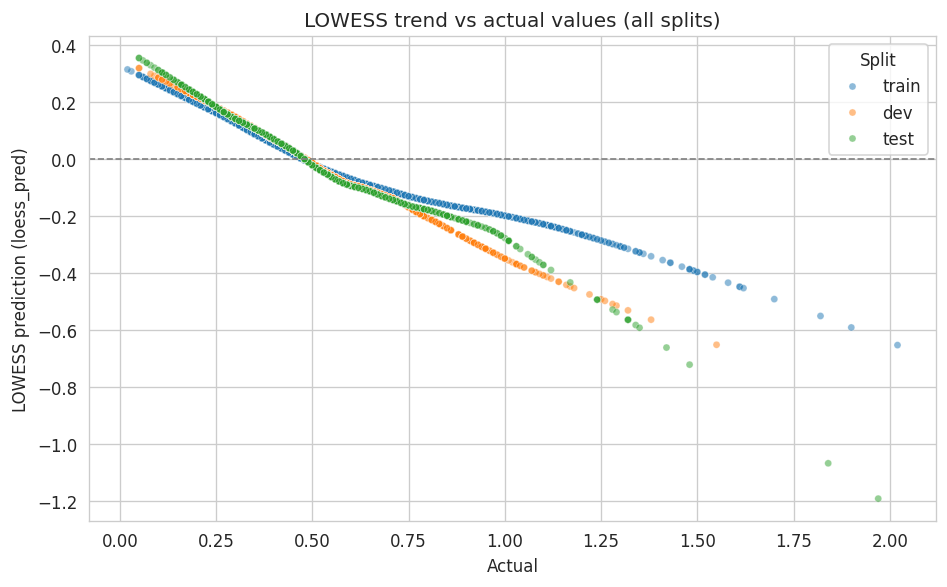

,id,actual,prediction,split,residual,loess_pred,deviation,threshold,is_poor
0,FBtr0081843,0.34,0.41,train,0.07,0.093926,-0.023926,0.205387,False
1,FBtr0084166,0.73,0.82,train,0.09,-0.123376,0.213376,0.205387,False
2,FBtr0100446,0.78,0.60,train,-0.18,-0.141950,-0.038050,0.205387,False
3,FBtr0078857,0.61,0.69,train,0.08,-0.075209,0.155209,0.205387,False
4,FBtr0083574,0.92,0.64,train,-0.28,-0.179046,-0.100954,0.205387,False
...,...,...,...,...,...,...,...,...,...
6014,FBtr0089881,0.45,0.48,test,0.03,0.028499,0.001501,0.243240,False
6015,FBtr0079641,0.62,0.33,test,-0.29,-0.101649,-0.188351,0.243240,False
6016,FBtr0079559,0.85,0.59,test,-0.26,-0.199794,-0.060206,0.243240,False
6017,FBtr0300379,0.27,0.49,test,0.22,0.163677,0.056323,0.243240,False


In [58]:
fig, ax = plt.subplots(figsize=(8, 5))s

sns.scatterplot(
    data=dfOrig,
    x='actual',
    y='loess_pred',
    hue='split',
    alpha=0.5,
    s=18,
    ax=ax
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Actual')
ax.set_ylabel('LOWESS prediction (loess_pred)')
ax.set_title('LOWESS trend vs actual values (all splits)')
ax.legend(title='Split')
fig.tight_layout()
plt.show()
dfOrig

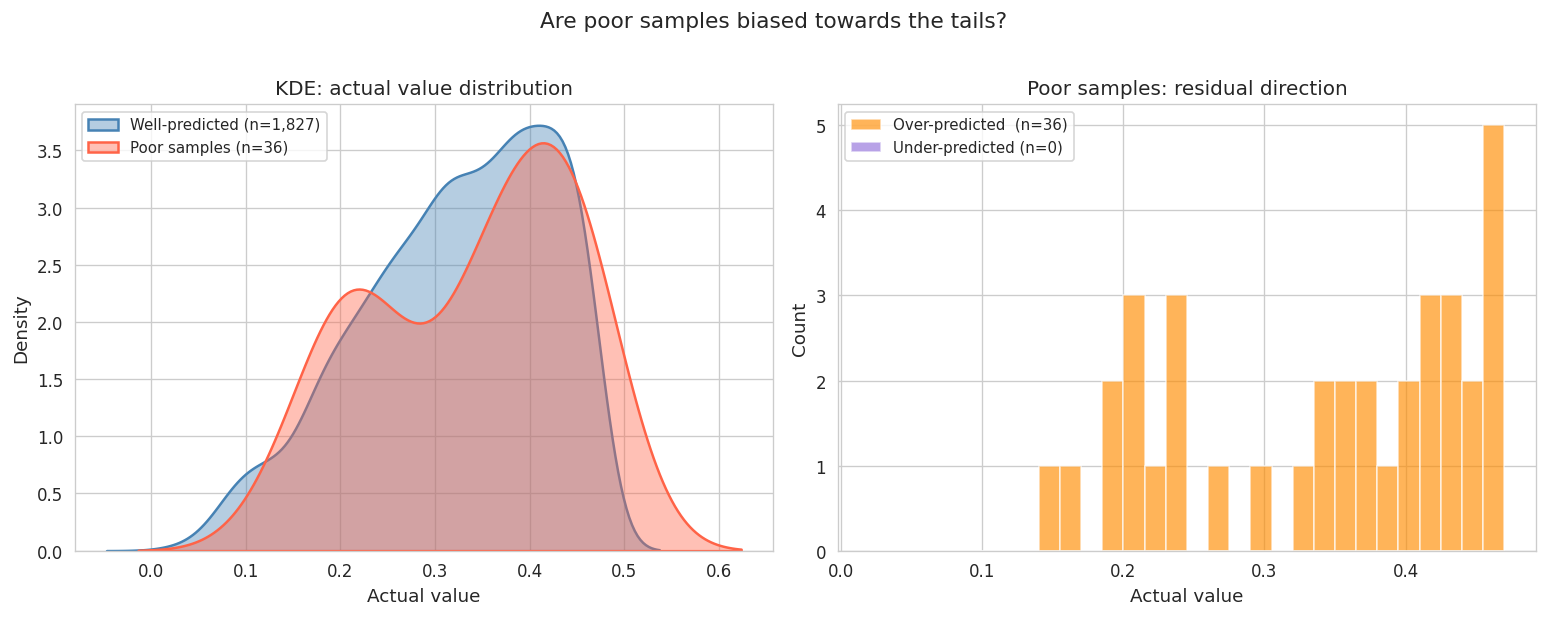


Poor sample actual-value summary:
count    36.0000
mean      0.3392
std       0.1048
min       0.1400
25%       0.2375
50%       0.3650
75%       0.4300
max       0.4700
Name: actual, dtype: float64

All samples actual-value summary:
count    1863.0000
mean        0.3229
std         0.1006
min         0.0200
25%         0.2500
50%         0.3400
75%         0.4100
max         0.4700
Name: actual, dtype: float64
Feature matrix: 6,062 transcripts × 68 features
Columns: ["5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA'

,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,3' UTR Length,90.000000,281.000000,140.527778,412.596606,-0.699747,13420.0,1.129461e-09,7.680333e-08,True
1,5' UTR Length,86.500000,157.000000,99.305556,249.324028,-0.660093,15518.5,5.527709e-08,1.879421e-06,True
2,CAT,0.006663,0.011127,0.006923,0.012854,-0.617791,19423.0,2.523277e-05,5.719428e-04,True
3,5' UTR GC Content,0.373470,0.428571,0.383318,0.424928,-0.592130,20850.0,1.662755e-04,2.214701e-03,True
4,mfe,90.915000,141.705000,105.486111,177.831386,-0.497241,20968.0,1.954148e-04,2.214701e-03,True
5,GAG,0.046691,0.031398,0.049534,0.032646,0.869776,45028.5,1.454388e-04,2.214701e-03,True
6,CCG,0.010590,0.015464,0.011383,0.017016,-0.531903,21591.5,4.099970e-04,3.982828e-03,True
7,AAA,0.019615,0.013309,0.022252,0.015583,0.571657,43711.0,7.074346e-04,6.013194e-03,True
8,CDS GC Content,0.538561,0.551807,0.527806,0.547202,-0.428667,22273.0,8.995143e-04,6.796331e-03,True
9,TGC,0.009808,0.015005,0.012479,0.017070,-0.422476,23908.0,4.973499e-03,3.381980e-02,True


In [65]:
## 4. Distribution of actual values — are poor samples biased to the tails?
df = dfOrig[(dfOrig['split'] == 'train') & (dfOrig['loess_pred'] > 0)]   # focus on train split for stratification analysis
poor_df = df[df['is_poor']]
good_df = df[~df['is_poor']]
#poor_df  = df[df['is_poor'] & (df['split'] == 'train')]
#good_df  = df[~df['is_poor'] & (df['split'] == 'train')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── KDE overlay: poor vs well-predicted ──────────────────────────────────────
ax = axes[0]
sns.kdeplot(good_df['actual'],  ax=ax, color='steelblue', fill=True, alpha=0.4,
            linewidth=1.5, label=f'Well-predicted (n={len(good_df):,})')
sns.kdeplot(poor_df['actual'],  ax=ax, color='tomato',    fill=True, alpha=0.4,
            linewidth=1.5, label=f'Poor samples (n={len(poor_df):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('KDE: actual value distribution', fontsize=12)
ax.legend(fontsize=9)

# ── Histogram of poor samples, split by over- / under-prediction ─────────────
ax = axes[1]
over  = poor_df[poor_df['residual'] > 0]['actual']
under = poor_df[poor_df['residual'] < 0]['actual']
bins  = np.histogram_bin_edges(df['actual'], bins=30)
ax.hist(over,  bins=bins, color='darkorange',   alpha=0.65,
        label=f'Over-predicted  (n={len(over):,})')
ax.hist(under, bins=bins, color='mediumpurple', alpha=0.65,
        label=f'Under-predicted (n={len(under):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Poor samples: residual direction', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Are poor samples biased towards the tails?', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nPoor sample actual-value summary:')
print(poor_df['actual'].describe().round(4))
print('\nAll samples actual-value summary:')
print(df['actual'].describe().round(4))
## 5. Load input features
EXTRA_FEAT_PATH  = os.path.join(REPO_ROOT, 'output/data/codons/extraFeatures.csv')
VIENNA_FEAT_PATH = os.path.join(REPO_ROOT, 'output/data/codons/vienna_features.csv')

extra_df = pd.read_csv(EXTRA_FEAT_PATH, index_col=0)
extra_df.index = extra_df.index.astype(str)

vienna_df = pd.read_csv(VIENNA_FEAT_PATH)
if 'id' in vienna_df.columns:
    vienna_df = vienna_df.set_index('id')[['mfe']]
vienna_df.index = vienna_df.index.astype(str)

features_df = extra_df.join(vienna_df, how='left')

# Drop label columns — not input features
drop_cols = [c for c in ['Decay Rate', 'Residuals'] if c in features_df.columns]
features_df = features_df.drop(columns=drop_cols)

print(f'Feature matrix: {features_df.shape[0]:,} transcripts × {features_df.shape[1]} features')
print('Columns:', features_df.columns.tolist())
## 6. Merge predictions with features
merged = df.set_index('id').join(features_df, how='inner')

n_matched   = len(merged)
n_unmatched = len(df) - n_matched
print(f'Matched to features : {n_matched:,}')
print(f'Unmatched (no feat) : {n_unmatched:,}')
print(f'Poor after merge    : {merged["is_poor"].sum():,}')
print(f'Good after merge    : {(~merged["is_poor"]).sum():,}')

feature_cols = [c for c in features_df.columns if c in merged.columns]
print(f'\n{len(feature_cols)} feature columns available for comparison')
## 7. Mann-Whitney U test for each feature (FDR corrected)
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


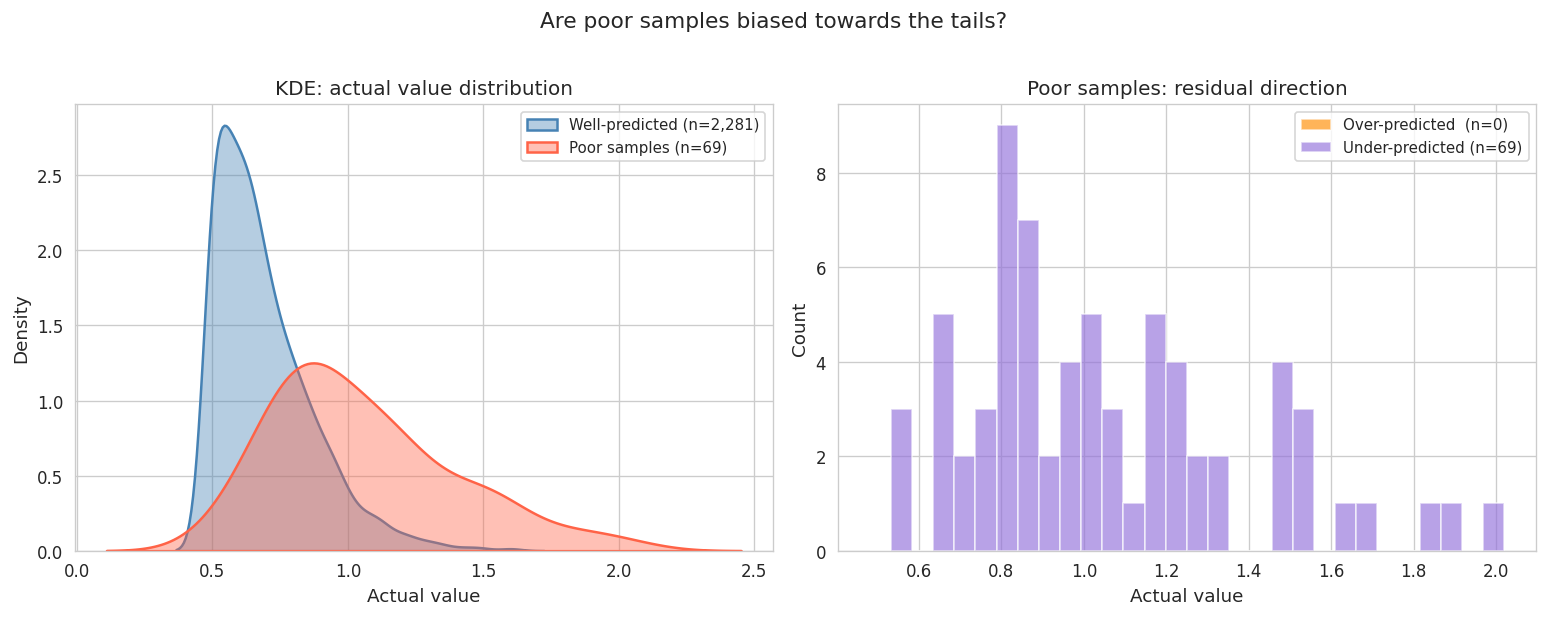


Poor sample actual-value summary:
count    69.0000
mean      1.0538
std       0.3350
min       0.5400
25%       0.8200
50%       0.9800
75%       1.2100
max       2.0200
Name: actual, dtype: float64

All samples actual-value summary:
count    2350.0000
mean        0.7001
std         0.1953
min         0.4800
25%         0.5600
50%         0.6500
75%         0.7900
max         2.0200
Name: actual, dtype: float64
Feature matrix: 6,062 transcripts × 68 features
Columns: ["5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA'

,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,3' UTR Length,307.000000,199.000000,451.449275,312.772907,0.421262,97966.5,0.000519,0.031211,True
1,ATC,0.023635,0.019968,0.026994,0.021705,0.457621,96427.5,0.001406,0.031211,True
2,3' UTR GC Content,0.354733,0.332769,0.360759,0.332755,0.419035,96758.0,0.001142,0.031211,True
3,CAA,0.010753,0.015656,0.013790,0.018592,-0.341521,61395.0,0.001836,0.031211,True
4,AAA,0.011737,0.016711,0.015847,0.019357,-0.270026,62384.5,0.003313,0.037177,True
5,GCC,0.032558,0.027115,0.034711,0.028786,0.389351,94754.5,0.003827,0.037177,True
6,TTC,0.019802,0.017115,0.025042,0.019081,0.516845,95015.5,0.003292,0.037177,True
7,GAA,0.016706,0.019881,0.017810,0.022115,-0.316845,63390.0,0.005850,0.049728,True
8,CTG,0.036145,0.029940,0.038275,0.032327,0.325137,93394.0,0.008119,0.061345,False
9,ACC,0.020323,0.016949,0.021952,0.018346,0.366718,92607.5,0.012230,0.083162,False


In [66]:
## 4. Distribution of actual values — are poor samples biased to the tails?
df = dfOrig[(dfOrig['split'] == 'train') & (dfOrig['loess_pred'] <= 0)]    # focus on train split for stratification analysis
poor_df = df[df['is_poor']]
good_df = df[~df['is_poor']]
#poor_df  = df[df['is_poor'] & (df['split'] == 'train')]
#good_df  = df[~df['is_poor'] & (df['split'] == 'train')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── KDE overlay: poor vs well-predicted ──────────────────────────────────────
ax = axes[0]
sns.kdeplot(good_df['actual'],  ax=ax, color='steelblue', fill=True, alpha=0.4,
            linewidth=1.5, label=f'Well-predicted (n={len(good_df):,})')
sns.kdeplot(poor_df['actual'],  ax=ax, color='tomato',    fill=True, alpha=0.4,
            linewidth=1.5, label=f'Poor samples (n={len(poor_df):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('KDE: actual value distribution', fontsize=12)
ax.legend(fontsize=9)

# ── Histogram of poor samples, split by over- / under-prediction ─────────────
ax = axes[1]
over  = poor_df[poor_df['residual'] > 0]['actual']
under = poor_df[poor_df['residual'] < 0]['actual']
bins  = np.histogram_bin_edges(df['actual'], bins=30)
ax.hist(over,  bins=bins, color='darkorange',   alpha=0.65,
        label=f'Over-predicted  (n={len(over):,})')
ax.hist(under, bins=bins, color='mediumpurple', alpha=0.65,
        label=f'Under-predicted (n={len(under):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Poor samples: residual direction', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Are poor samples biased towards the tails?', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nPoor sample actual-value summary:')
print(poor_df['actual'].describe().round(4))
print('\nAll samples actual-value summary:')
print(df['actual'].describe().round(4))
## 5. Load input features
EXTRA_FEAT_PATH  = os.path.join(REPO_ROOT, 'output/data/codons/extraFeatures.csv')
VIENNA_FEAT_PATH = os.path.join(REPO_ROOT, 'output/data/codons/vienna_features.csv')

extra_df = pd.read_csv(EXTRA_FEAT_PATH, index_col=0)
extra_df.index = extra_df.index.astype(str)

vienna_df = pd.read_csv(VIENNA_FEAT_PATH)
if 'id' in vienna_df.columns:
    vienna_df = vienna_df.set_index('id')[['mfe']]
vienna_df.index = vienna_df.index.astype(str)

features_df = extra_df.join(vienna_df, how='left')

# Drop label columns — not input features
drop_cols = [c for c in ['Decay Rate', 'Residuals'] if c in features_df.columns]
features_df = features_df.drop(columns=drop_cols)

print(f'Feature matrix: {features_df.shape[0]:,} transcripts × {features_df.shape[1]} features')
print('Columns:', features_df.columns.tolist())
## 6. Merge predictions with features
merged = df.set_index('id').join(features_df, how='inner')

n_matched   = len(merged)
n_unmatched = len(df) - n_matched
print(f'Matched to features : {n_matched:,}')
print(f'Unmatched (no feat) : {n_unmatched:,}')
print(f'Poor after merge    : {merged["is_poor"].sum():,}')
print(f'Good after merge    : {(~merged["is_poor"]).sum():,}')

feature_cols = [c for c in features_df.columns if c in merged.columns]
print(f'\n{len(feature_cols)} feature columns available for comparison')
## 7. Mann-Whitney U test for each feature (FDR corrected)
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


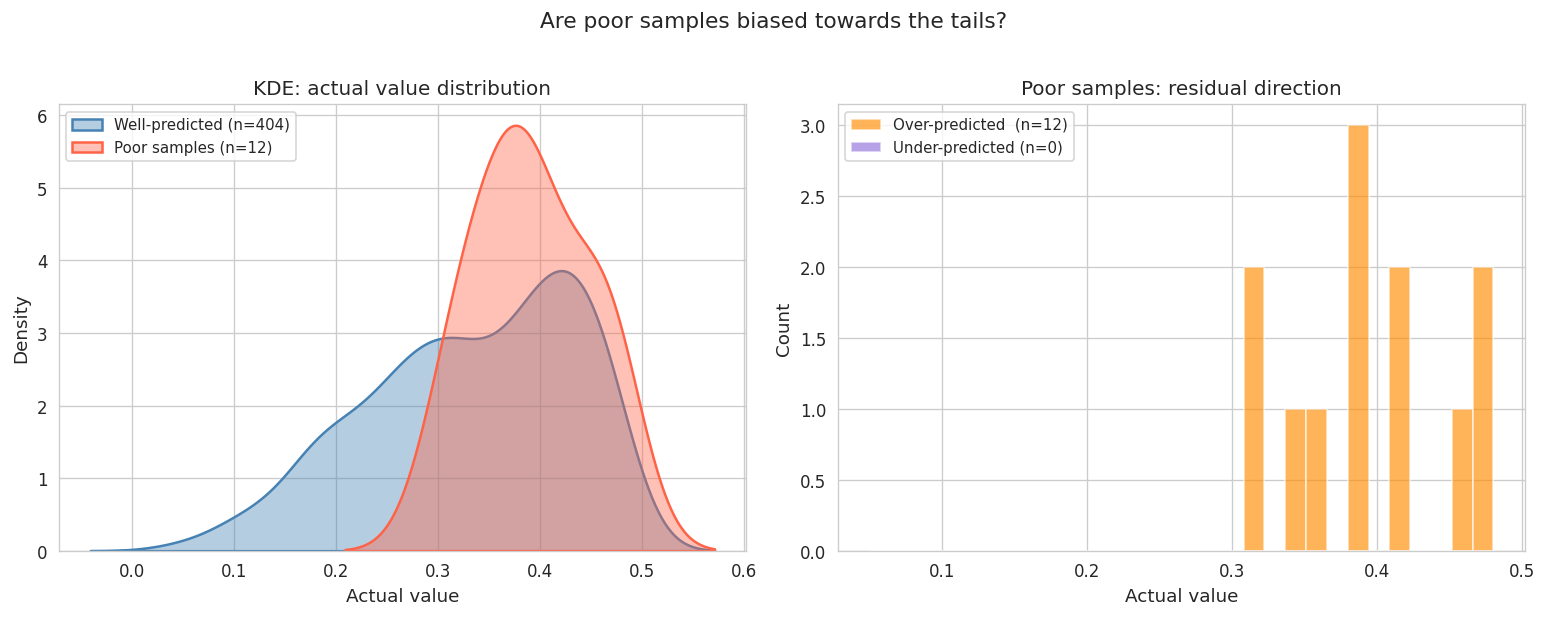


Poor sample actual-value summary:
count    12.0000
mean      0.3917
std       0.0556
min       0.3100
25%       0.3550
50%       0.3800
75%       0.4300
max       0.4700
Name: actual, dtype: float64

All samples actual-value summary:
count    416.0000
mean       0.3356
std        0.1007
min        0.0500
25%        0.2675
50%        0.3500
75%        0.4200
max        0.4800
Name: actual, dtype: float64
Feature matrix: 6,062 transcripts × 68 features
Columns: ["5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA', 'GGG',

,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,3' UTR Length,93.000000,303.500000,115.333333,427.646040,-0.798414,838.0,0.000112,0.007620,True
1,5' UTR Length,79.500000,151.500000,80.500000,249.754950,-0.709085,939.5,0.000300,0.010187,True
2,ACG,0.006564,0.015038,0.006983,0.016252,-1.013615,1029.5,0.000683,0.015472,True
3,mfe,61.595000,155.650000,84.260833,189.659950,-0.518024,1156.0,0.002015,0.034247,True
4,3' UTR GC Content,0.296681,0.349250,0.301588,0.349082,-0.681304,1219.0,0.003340,0.045421,True
5,AGG,0.011933,0.006144,0.018795,0.009544,0.883063,3520.5,0.007494,0.063697,False
6,5' UTR GC Content,0.357143,0.422661,0.357334,0.418264,-0.892641,1312.0,0.006769,0.063697,False
7,AAA,0.024225,0.013982,0.025129,0.016128,0.765160,3559.0,0.005708,0.063697,False
8,CDS Length,837.000000,1663.500000,1083.500000,2133.452970,-0.383024,1375.5,0.010670,0.080620,False
9,TTC,0.011280,0.017056,0.011584,0.019629,-0.700650,1431.5,0.015654,0.096768,False


In [67]:
## 4. Distribution of actual values — are poor samples biased to the tails?
df = dfOrig[(dfOrig['split'] == 'dev') & (dfOrig['loess_pred'] > 0)]   # focus on train split for stratification analysis
poor_df = df[df['is_poor']]
good_df = df[~df['is_poor']]
#poor_df  = df[df['is_poor'] & (df['split'] == 'train')]
#good_df  = df[~df['is_poor'] & (df['split'] == 'train')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── KDE overlay: poor vs well-predicted ──────────────────────────────────────
ax = axes[0]
sns.kdeplot(good_df['actual'],  ax=ax, color='steelblue', fill=True, alpha=0.4,
            linewidth=1.5, label=f'Well-predicted (n={len(good_df):,})')
sns.kdeplot(poor_df['actual'],  ax=ax, color='tomato',    fill=True, alpha=0.4,
            linewidth=1.5, label=f'Poor samples (n={len(poor_df):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('KDE: actual value distribution', fontsize=12)
ax.legend(fontsize=9)

# ── Histogram of poor samples, split by over- / under-prediction ─────────────
ax = axes[1]
over  = poor_df[poor_df['residual'] > 0]['actual']
under = poor_df[poor_df['residual'] < 0]['actual']
bins  = np.histogram_bin_edges(df['actual'], bins=30)
ax.hist(over,  bins=bins, color='darkorange',   alpha=0.65,
        label=f'Over-predicted  (n={len(over):,})')
ax.hist(under, bins=bins, color='mediumpurple', alpha=0.65,
        label=f'Under-predicted (n={len(under):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Poor samples: residual direction', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Are poor samples biased towards the tails?', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nPoor sample actual-value summary:')
print(poor_df['actual'].describe().round(4))
print('\nAll samples actual-value summary:')
print(df['actual'].describe().round(4))
## 5. Load input features
EXTRA_FEAT_PATH  = os.path.join(REPO_ROOT, 'output/data/codons/extraFeatures.csv')
VIENNA_FEAT_PATH = os.path.join(REPO_ROOT, 'output/data/codons/vienna_features.csv')

extra_df = pd.read_csv(EXTRA_FEAT_PATH, index_col=0)
extra_df.index = extra_df.index.astype(str)

vienna_df = pd.read_csv(VIENNA_FEAT_PATH)
if 'id' in vienna_df.columns:
    vienna_df = vienna_df.set_index('id')[['mfe']]
vienna_df.index = vienna_df.index.astype(str)

features_df = extra_df.join(vienna_df, how='left')

# Drop label columns — not input features
drop_cols = [c for c in ['Decay Rate', 'Residuals'] if c in features_df.columns]
features_df = features_df.drop(columns=drop_cols)

print(f'Feature matrix: {features_df.shape[0]:,} transcripts × {features_df.shape[1]} features')
print('Columns:', features_df.columns.tolist())
## 6. Merge predictions with features
merged = df.set_index('id').join(features_df, how='inner')

n_matched   = len(merged)
n_unmatched = len(df) - n_matched
print(f'Matched to features : {n_matched:,}')
print(f'Unmatched (no feat) : {n_unmatched:,}')
print(f'Poor after merge    : {merged["is_poor"].sum():,}')
print(f'Good after merge    : {(~merged["is_poor"]).sum():,}')

feature_cols = [c for c in features_df.columns if c in merged.columns]
print(f'\n{len(feature_cols)} feature columns available for comparison')
## 7. Mann-Whitney U test for each feature (FDR corrected)
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


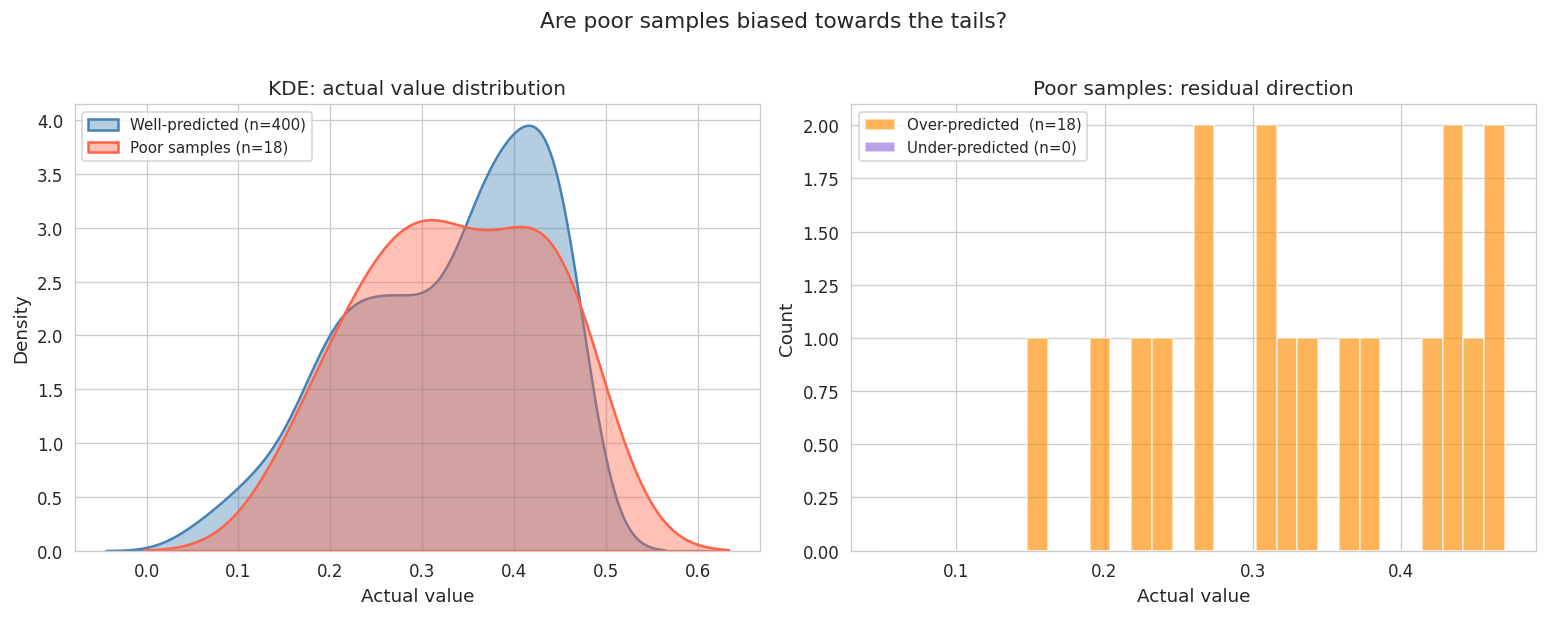


Poor sample actual-value summary:
count    18.0000
mean      0.3356
std       0.0972
min       0.1600
25%       0.2625
50%       0.3250
75%       0.4275
max       0.4700
Name: actual, dtype: float64

All samples actual-value summary:
count    418.0000
mean       0.3278
std        0.1038
min        0.0500
25%        0.2500
50%        0.3500
75%        0.4200
max        0.4700
Name: actual, dtype: float64
Feature matrix: 6,062 transcripts × 68 features
Columns: ["5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA', 'GGG',

,feature,poor_median,good_median,poor_mean,good_mean,cohens_d,mwu_stat,p_value,padj,sig_fdr
0,3' UTR Length,104.500000,296.000000,153.666667,423.705000,-0.703033,1583.5,0.000058,0.003944,True
1,5' UTR Length,100.500000,151.000000,125.500000,244.847500,-0.533819,1966.0,0.001122,0.026236,True
2,TTG,0.021694,0.013036,0.021553,0.013976,0.924249,5229.5,0.001157,0.026236,True
3,3' UTR GC Content,0.317675,0.350908,0.296156,0.350784,-0.929007,2104.0,0.002857,0.048577,True
4,CGC,0.013295,0.019320,0.014381,0.020639,-0.586009,2246.5,0.006966,0.069927,False
5,GAG,0.049555,0.032530,0.044344,0.033376,0.541386,4889.0,0.010175,0.069927,False
6,5' UTR GC Content,0.386482,0.426718,0.385150,0.423344,-0.553170,2327.0,0.011151,0.069927,False
7,ATT,0.019959,0.012818,0.020211,0.014000,0.753783,4922.0,0.008396,0.069927,False
8,GAT,0.029516,0.021761,0.029885,0.021403,0.731122,4932.0,0.007915,0.069927,False
9,AAA,0.019554,0.013671,0.024541,0.015757,0.797539,4990.0,0.005582,0.069927,False


In [68]:
## 4. Distribution of actual values — are poor samples biased to the tails?
df = dfOrig[(dfOrig['split'] == 'test') & (dfOrig['loess_pred'] > 0)]   # focus on train split for stratification analysis
poor_df = df[df['is_poor']]
good_df = df[~df['is_poor']]
#poor_df  = df[df['is_poor'] & (df['split'] == 'train')]
#good_df  = df[~df['is_poor'] & (df['split'] == 'train')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── KDE overlay: poor vs well-predicted ──────────────────────────────────────
ax = axes[0]
sns.kdeplot(good_df['actual'],  ax=ax, color='steelblue', fill=True, alpha=0.4,
            linewidth=1.5, label=f'Well-predicted (n={len(good_df):,})')
sns.kdeplot(poor_df['actual'],  ax=ax, color='tomato',    fill=True, alpha=0.4,
            linewidth=1.5, label=f'Poor samples (n={len(poor_df):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('KDE: actual value distribution', fontsize=12)
ax.legend(fontsize=9)

# ── Histogram of poor samples, split by over- / under-prediction ─────────────
ax = axes[1]
over  = poor_df[poor_df['residual'] > 0]['actual']
under = poor_df[poor_df['residual'] < 0]['actual']
bins  = np.histogram_bin_edges(df['actual'], bins=30)
ax.hist(over,  bins=bins, color='darkorange',   alpha=0.65,
        label=f'Over-predicted  (n={len(over):,})')
ax.hist(under, bins=bins, color='mediumpurple', alpha=0.65,
        label=f'Under-predicted (n={len(under):,})')
ax.set_xlabel('Actual value', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Poor samples: residual direction', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Are poor samples biased towards the tails?', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nPoor sample actual-value summary:')
print(poor_df['actual'].describe().round(4))
print('\nAll samples actual-value summary:')
print(df['actual'].describe().round(4))
## 5. Load input features
EXTRA_FEAT_PATH  = os.path.join(REPO_ROOT, 'output/data/codons/extraFeatures.csv')
VIENNA_FEAT_PATH = os.path.join(REPO_ROOT, 'output/data/codons/vienna_features.csv')

extra_df = pd.read_csv(EXTRA_FEAT_PATH, index_col=0)
extra_df.index = extra_df.index.astype(str)

vienna_df = pd.read_csv(VIENNA_FEAT_PATH)
if 'id' in vienna_df.columns:
    vienna_df = vienna_df.set_index('id')[['mfe']]
vienna_df.index = vienna_df.index.astype(str)

features_df = extra_df.join(vienna_df, how='left')

# Drop label columns — not input features
drop_cols = [c for c in ['Decay Rate', 'Residuals'] if c in features_df.columns]
features_df = features_df.drop(columns=drop_cols)

print(f'Feature matrix: {features_df.shape[0]:,} transcripts × {features_df.shape[1]} features')
print('Columns:', features_df.columns.tolist())
## 6. Merge predictions with features
merged = df.set_index('id').join(features_df, how='inner')

n_matched   = len(merged)
n_unmatched = len(df) - n_matched
print(f'Matched to features : {n_matched:,}')
print(f'Unmatched (no feat) : {n_unmatched:,}')
print(f'Poor after merge    : {merged["is_poor"].sum():,}')
print(f'Good after merge    : {(~merged["is_poor"]).sum():,}')

feature_cols = [c for c in features_df.columns if c in merged.columns]
print(f'\n{len(feature_cols)} feature columns available for comparison')
## 7. Mann-Whitney U test for each feature (FDR corrected)
poor_feat = merged.loc[ merged['is_poor'], feature_cols]
good_feat = merged.loc[~merged['is_poor'], feature_cols]

rows = []
for col in feature_cols:
    a = poor_feat[col].dropna()
    b = good_feat[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    stat, pval = mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d: scale-invariant effect size so lengths/GC/codons are comparable
    n1, n2   = len(a), len(b)
    pooled   = np.sqrt(((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))
    cohens_d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0
    rows.append({
        'feature':      col,
        'poor_median':  a.median(),
        'good_median':  b.median(),
        'poor_mean':    a.mean(),
        'good_mean':    b.mean(),
        'cohens_d':     cohens_d,
        'mwu_stat':     stat,
        'p_value':      pval,
    })

stats_df = pd.DataFrame(rows)
_, padj, _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df['padj']    = padj
stats_df['sig_fdr'] = padj < 0.05
stats_df = stats_df.sort_values('padj').reset_index(drop=True)

print(f'Significant features (FDR < 0.05): {stats_df["sig_fdr"].sum()}')
stats_df.head(20)


In [76]:
df = dfOrig[(dfOrig['split'] == 'train') & (dfOrig['loess_pred'] > 0)]

posLOESS_negSTD = np.where(
        df['loess_pred'] > 0,
        df['deviation'] < -(df['threshold']/2*1.25),
        False
)    
df['plns'] = posLOESS_negSTD
df


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,id,actual,prediction,split,residual,loess_pred,deviation,threshold,is_poor,plns
0,FBtr0081843,0.34,0.41,train,0.07,0.093926,-0.023926,0.205387,False,False
5,FBtr0085546,0.33,0.62,train,0.29,0.101475,0.188525,0.205387,False,False
6,FBtr0081981,0.33,0.40,train,0.07,0.101475,-0.031475,0.205387,False,False
10,FBtr0302313,0.36,0.38,train,0.02,0.078900,-0.058900,0.205387,False,False
12,FBtr0085390,0.21,0.62,train,0.41,0.187070,0.222930,0.205387,True,False
...,...,...,...,...,...,...,...,...,...,...
4204,FBtr0302874,0.39,0.54,train,0.15,0.057035,0.092965,0.205387,False,False
4207,FBtr0081228,0.20,0.48,train,0.28,0.193712,0.086288,0.205387,False,False
4209,FBtr0310541,0.18,0.29,train,0.11,0.207150,-0.097150,0.205387,False,False
4210,FBtr0089223,0.35,0.39,train,0.04,0.086338,-0.046338,0.205387,False,False


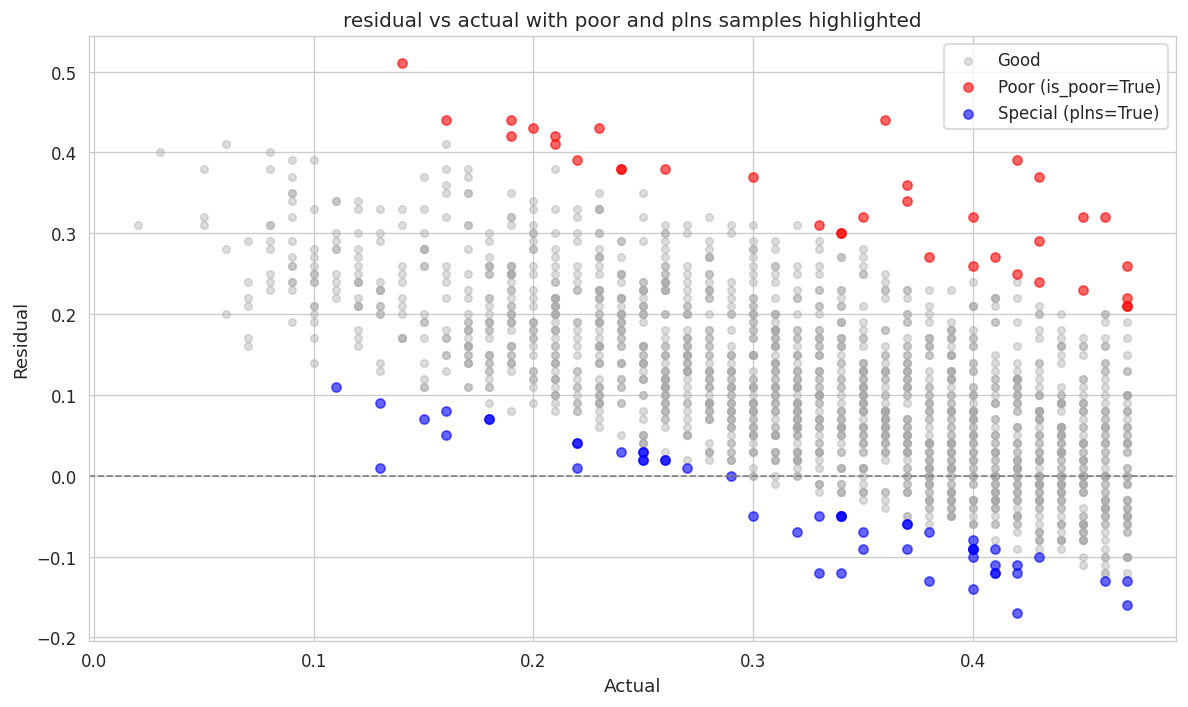

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot good samples (not poor, not plns) in dark grey
good_mask = ~df['is_poor'] & ~df['plns']
ax.scatter(df.loc[good_mask, 'actual'], df.loc[good_mask, 'residual'],
           c='darkgrey', alpha=0.4, s=20, label='Good')

# Plot poor samples (is_poor=True) in red
poor_mask = df['is_poor']
ax.scatter(df.loc[poor_mask, 'actual'], df.loc[poor_mask, 'residual'],
           c='red', alpha=0.6, s=30, label='Poor (is_poor=True)')

# Plot plns samples (plns=True) in blue
plns_mask = df['plns']
ax.scatter(df.loc[plns_mask, 'actual'], df.loc[plns_mask, 'residual'],
           c='blue', alpha=0.6, s=30, label='Special (plns=True)')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Actual', fontsize=11)
ax.set_ylabel('Residual', fontsize=11)
ax.set_title('residual vs actual with poor and plns samples highlighted', fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(ZONE_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

# Build a quick lookup: feature -> (d_pos, sig_pos, d_neg, sig_neg)
zp = zone_stats_pos.set_index('feature')
zn = zone_stats_neg.set_index('feature')

for ax, feat in zip(axes, ZONE_FEATURES):
    sns.boxplot(data=zone_df, x='group', y=feat,
                order=group_order, palette=zone_colors,
                linewidth=0.8, ax=ax, flierprops=dict(marker='.', markersize=2))


for ax in axes[len(ZONE_FEATURES):]:
    ax.set_visible(False)

fig.suptitle('Zone-matched comparison: poor vs good within same LOWESS region', fontsize=13)
fig.tight_layout()
plt.show()

group
neither    1775
plns         52
is_poor      36
Name: count, dtype: int64




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

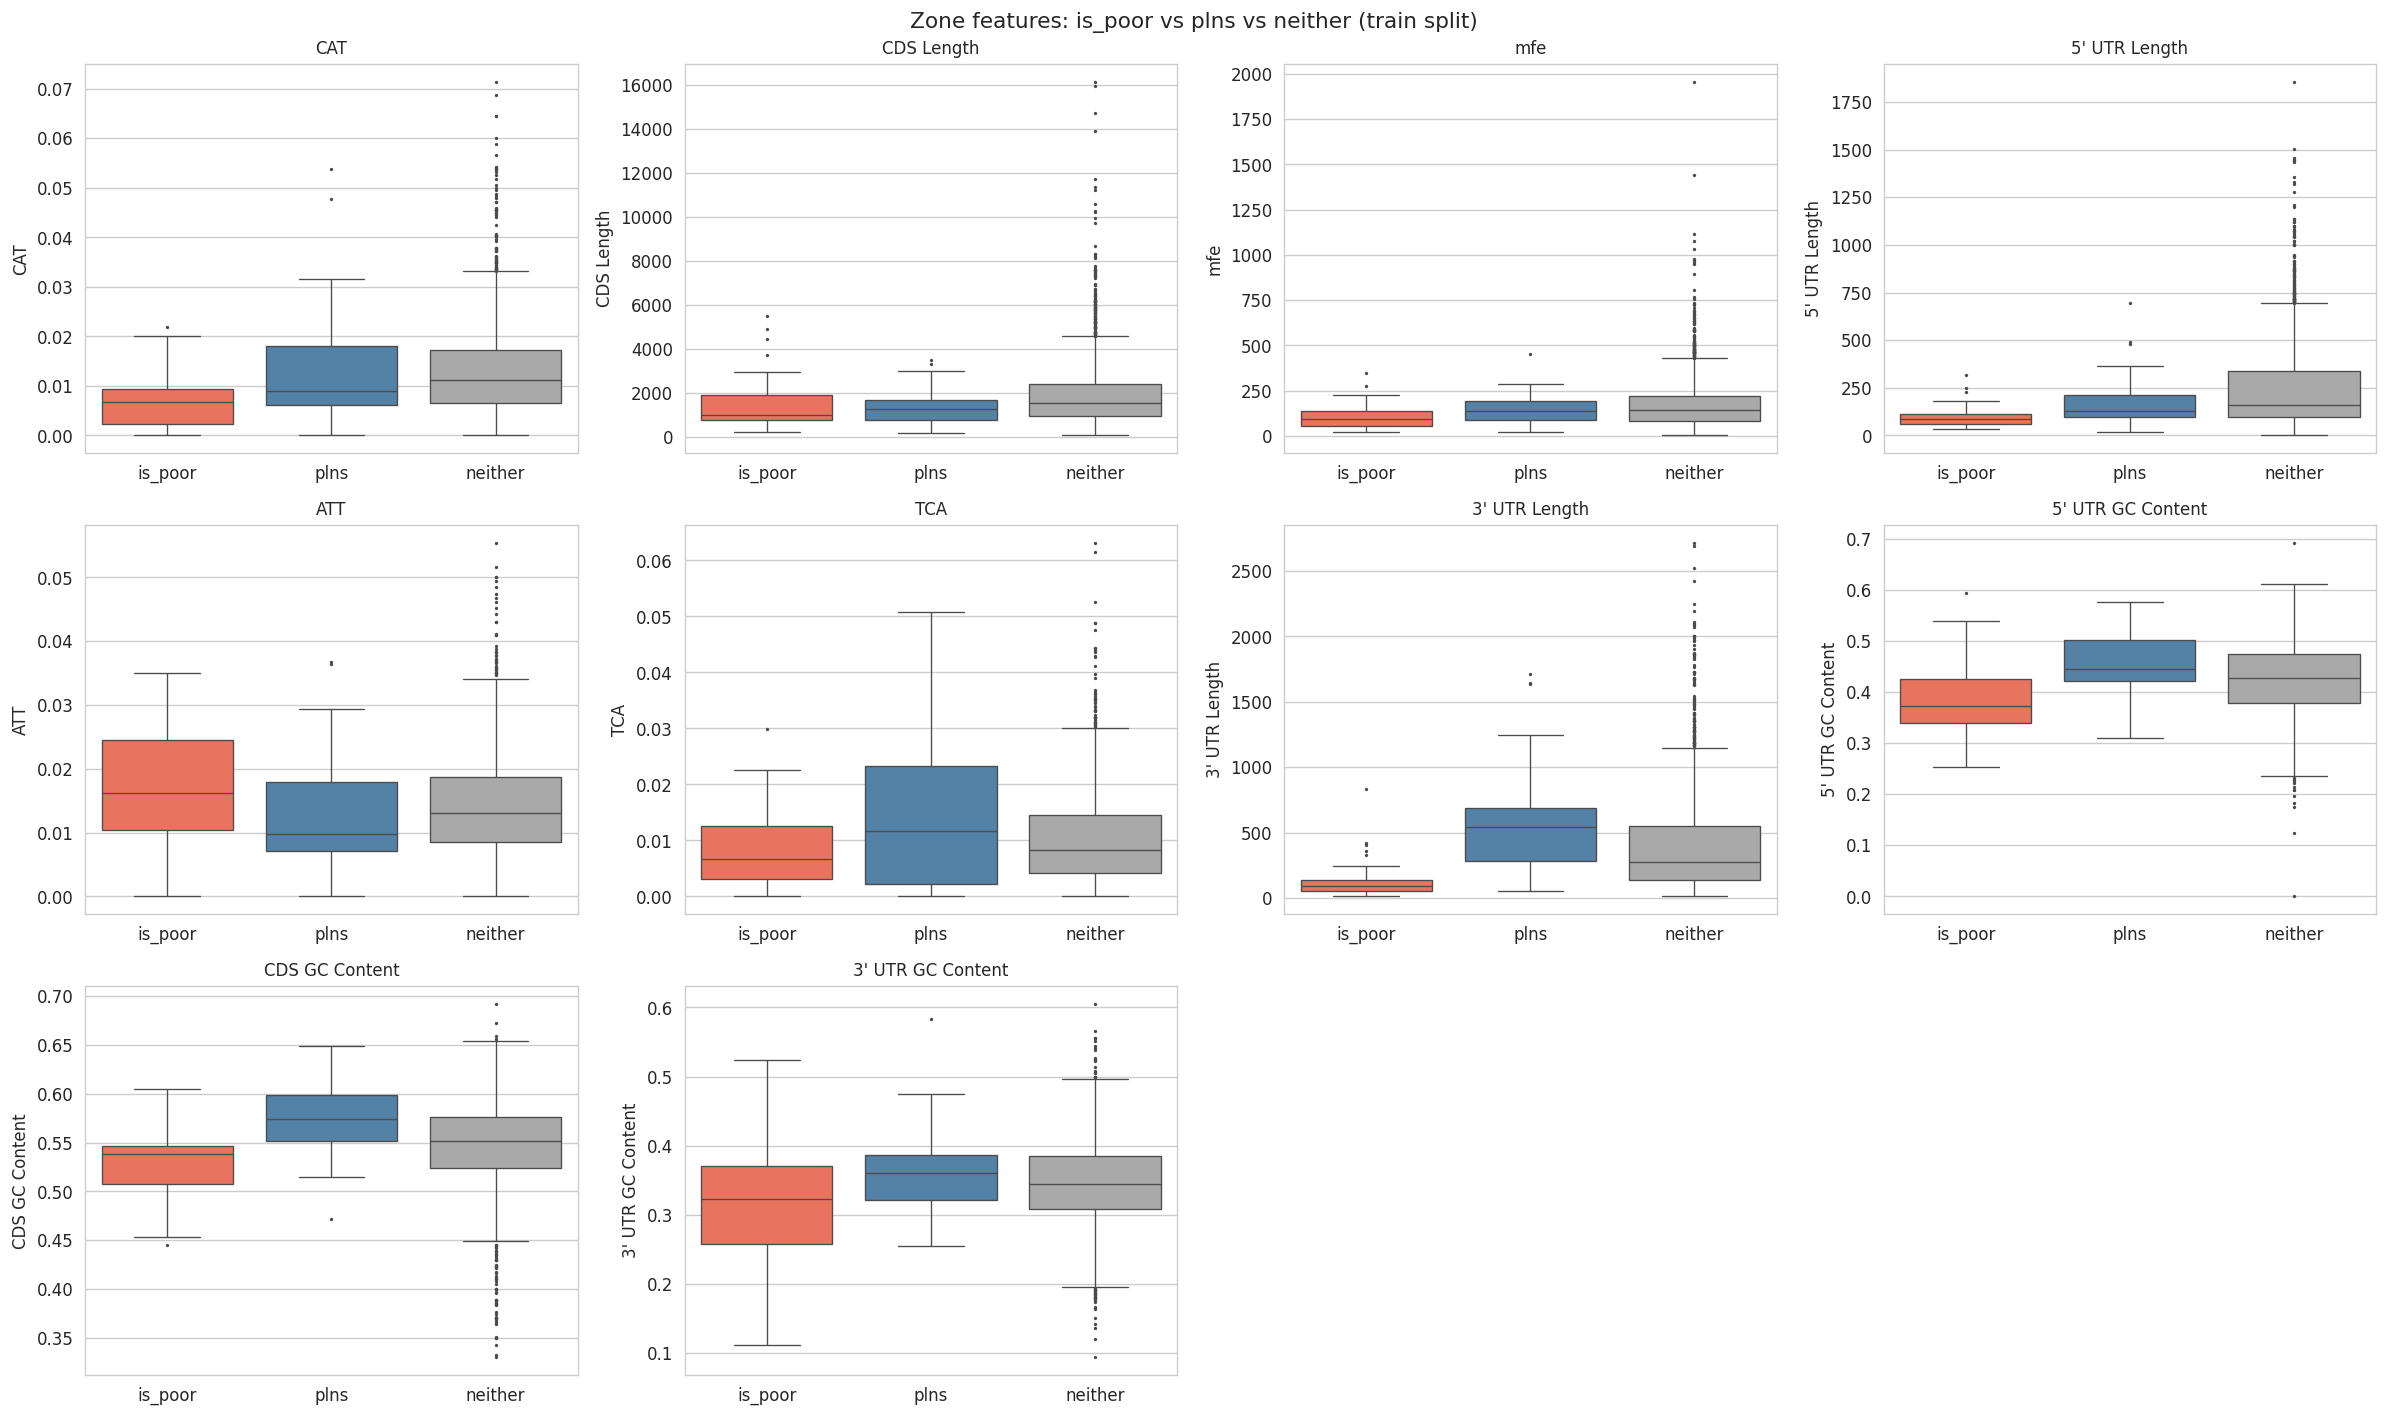

In [78]:
# ── Merge df (train split, has plns flag) with extra features ─────────────────
df_plns_merged = df.set_index('id').join(features_df, how='inner')

# Build group label: is_poor > plns > neither
# (is_poor takes precedence if a sample is flagged as both)
df_plns_merged['group'] = np.select(
    [df_plns_merged['is_poor'], df_plns_merged['plns']],
    ['is_poor', 'plns'],
    default='neither'
)

print(df_plns_merged['group'].value_counts())

# ── Boxplots for each ZONE_FEATURE split by is_poor / plns / neither ──────────
plns_grp_order  = ['is_poor', 'plns', 'neither']
plns_grp_colors = {'is_poor': 'tomato', 'plns': 'steelblue', 'neither': 'darkgrey'}

n_cols = 4
n_rows = int(np.ceil(len(ZONE_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, ZONE_FEATURES):
    sns.boxplot(data=df_plns_merged, x='group', y=feat,
                order=plns_grp_order, palette=plns_grp_colors,
                linewidth=0.8, ax=ax, flierprops=dict(marker='.', markersize=2))
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

for ax in axes[len(ZONE_FEATURES):]:
    ax.set_visible(False)

fig.suptitle('Zone features: is_poor vs plns vs neither (train split)', fontsize=13)
fig.tight_layout()
plt.show()
